In [1]:
# additional cells for segmentation module

!pip install hydra-core omegaconf iopath --quiet

import sys
sys.path = [p for p in sys.path if 'segmentation-module' not in p]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00


In [1]:
################################
################################
################################
# take user input
################################
################################
################################

In [2]:
from IPython.display import display
from ipywidgets import FileUpload
from pathlib import Path

# Configure where you want the uploaded images saved
SAVE_DIR = Path("/kaggle/working/input_images")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Create upload widgets
top_view_upload = FileUpload(
    accept='image/*',
    multiple=False,
    description='Top View'
)

side_view_upload = FileUpload(
    accept='image/*',
    multiple=False,
    description='Side View'
)

print("Upload TOP VIEW image:")
display(top_view_upload)

print("\nUpload SIDE VIEW image:")
display(side_view_upload)

Upload TOP VIEW image:


FileUpload(value=(), accept='image/*', description='Top View')


Upload SIDE VIEW image:


FileUpload(value=(), accept='image/*', description='Side View')

In [3]:
from pathlib import Path

SAVE_DIR = Path("/kaggle/working/input_images")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Top image
top_uploaded = top_view_upload.value[0]

with open(SAVE_DIR / "top.jpg", "wb") as f:
    f.write(top_uploaded["content"])

# Side image
side_uploaded = side_view_upload.value[0]

with open(SAVE_DIR / "side.jpg", "wb") as f:
    f.write(side_uploaded["content"])

print("Images saved successfully.")
print("Input image directory is:" , SAVE_DIR)

Images saved successfully.
Input image directory is: /kaggle/working/input_images


In [4]:
################################
################################
################################
# segmentation module class
################################
################################
################################

In [5]:
import os
import cv2
import json
import math
import time
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import sys

# 1. Point this exactly to the dataset folder containing the 'sam2' directory
SEGMENTATION_MODULE_DIR = "/kaggle/input/datasets/ifty3110/segmentation-module-checkpoints-config"

if str(SEGMENTATION_MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(SEGMENTATION_MODULE_DIR))

# 2. Now these imports will find the folder correctly!
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator


class SegmentationModule:
    """
    A segmentation module for food image segmentation using SAM2.
    """

    def __init__(self, checkpoint, model_config, device=None):
        """
        Initialize the SegmentationModule.

        Args:
            checkpoint   (str): Path to the SAM2 .pt checkpoint file.
            model_config (str): SAM2 config filename (e.g. 'sam2_hiera_l.yaml').
            device       (str): 'cuda' or 'cpu'. Auto-detected if None.
        """
        self.checkpoint   = checkpoint
        self.model_config = model_config
        self.device       = device or ("cuda" if torch.cuda.is_available() else "cpu")

        # SAM2 mask-generator parameters
        self.points_per_side        = 64
        self.points_per_batch       = 32
        self.pred_iou_thresh        = 0.8
        self.stability_score_thresh = 0.92
        self.box_nms_thresh         = 0.6
        self.min_mask_region_area   = 100
        self.dedup_iou_threshold    = 0.85
        self.min_area_ratio         = 0.02

        self.mask_generator = self._load_model()

    # ------------------------------------------------------------------
    # PRIVATE: Model loading
    # ------------------------------------------------------------------

    def _load_model(self):
        if not os.path.exists(self.checkpoint):
            raise FileNotFoundError(f"SAM2 checkpoint not found at {self.checkpoint}")

        if isinstance(self.model_config, str):
            config_value = self.model_config.strip()
            if config_value.endswith(".yaml") and "/" not in config_value:
                self.model_config = f"configs/sam2/{config_value}"        

        print(f"Loading SAM2 on {self.device}...")
        sam2 = build_sam2(
            self.model_config, self.checkpoint,
            device=self.device, apply_postprocessing=True
        )
        return SAM2AutomaticMaskGenerator(
            model=sam2,
            points_per_side=self.points_per_side,
            points_per_batch=self.points_per_batch,
            pred_iou_thresh=self.pred_iou_thresh,
            stability_score_thresh=self.stability_score_thresh,
            box_nms_thresh=self.box_nms_thresh,
            min_mask_region_area=self.min_mask_region_area,
        )

    # ------------------------------------------------------------------
    # PRIVATE: Helpers
    # ------------------------------------------------------------------

    def _load_image_rgb(self, input):
        """
        Accept a file path (str) or a PIL Image and return an RGB numpy array.
        """
        if isinstance(input, str):
            if not os.path.exists(input):
                raise FileNotFoundError(f"Image not found at {input}")
            image = cv2.imdecode(np.fromfile(input, dtype=np.uint8), cv2.IMREAD_COLOR)
            if image is None:
                raise ValueError(f"Failed to read image: {input}")
            return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        elif isinstance(input, Image.Image):
            return np.array(input.convert("RGB"))
        else:
            raise TypeError("Input must be a file path (str) or a PIL.Image object")

    def _generate_masks(self, image_rgb):
        """Run SAM2 and apply area-based filtering + deduplication."""
        masks = self.mask_generator.generate(image_rgb)
        masks = self._deduplicate_masks(masks)
        if masks:
            max_area = max(m["area"] for m in masks)
            masks = [m for m in masks if m["area"] >= self.min_area_ratio * max_area]
        return masks

    def _deduplicate_masks(self, masks):
        """Remove heavily overlapping masks, keeping the larger one."""
        masks = sorted(masks, key=lambda m: m["area"], reverse=True)
        kept = []
        for candidate in masks:
            c_mask = candidate["segmentation"]
            is_duplicate = False
            for kept_mask in kept:
                k_mask = kept_mask["segmentation"]
                intersection = np.logical_and(c_mask, k_mask).sum()
                union        = np.logical_or(c_mask,  k_mask).sum()
                if union > 0 and (intersection / union) > self.dedup_iou_threshold:
                    is_duplicate = True
                    break
            if not is_duplicate:
                kept.append(candidate)
        return kept

    # ------------------------------------------------------------------
    # PRIVATE: Visualization helpers
    # ------------------------------------------------------------------

    def _read_disp(self, path_str):
        """Read an image from disk and return (array, cmap) ready for imshow."""
        img = cv2.imread(str(path_str), cv2.IMREAD_UNCHANGED)
        if img is None:
            return None, None
        if img.ndim == 2:
            return img, 'gray'
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA), None
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), None

    def _style_ax(self, ax, title):
        """Apply uniform axis styling: title, no ticks, black border."""
        ax.set_title(title, fontsize=8, pad=3)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color('black'); sp.set_linewidth(2)

    # ------------------------------------------------------------------
    # PUBLIC: Input methods
    # ------------------------------------------------------------------

    def set_image_from_path(self, image_path):
        """Load and cache an image from a file path."""
        self._cached_image_rgb = self._load_image_rgb(image_path)
        self._cached_masks = None

    def set_image(self, image):
        """Load and cache a PIL Image."""
        self._cached_image_rgb = self._load_image_rgb(image)
        self._cached_masks = None

    def _get_cached_masks(self, input=None):
        """Return cached masks, generating them if not yet computed."""
        if input is not None:
            image_rgb = self._load_image_rgb(input)
            return image_rgb, self._generate_masks(image_rgb)

        if not hasattr(self, "_cached_image_rgb") or self._cached_image_rgb is None:
            raise RuntimeError(
                "No image loaded. Call set_image() or set_image_from_path() first, "
                "or pass an image directly to the method."
            )
        if self._cached_masks is None:
            self._cached_masks = self._generate_masks(self._cached_image_rgb)
        return self._cached_image_rgb, self._cached_masks

    # ------------------------------------------------------------------
    # PUBLIC: Output methods
    # ------------------------------------------------------------------

    def get_coordinates(self, input=None):
        """
        Return bounding-box coordinates for each detected segment.

        Returns list of dicts with keys:
            segment_id, bbox, area, predicted_iou, stability_score
        """
        _, masks = self._get_cached_masks(input)
        return [
            {
                "segment_id":      i,
                "bbox":            mask["bbox"],
                "area":            mask["area"],
                "predicted_iou":   round(mask["predicted_iou"],   4),
                "stability_score": round(mask["stability_score"], 4),
            }
            for i, mask in enumerate(masks)
        ]

    def get_masks(self, input=None):
        """
        Return binary boolean masks for each detected segment.

        Returns list of dicts with keys:
            segment_id, mask (np.ndarray bool H×W), area
        """
        _, masks = self._get_cached_masks(input)
        return [
            {
                "segment_id": i,
                "mask":       mask["segmentation"].astype(bool),
                "area":       mask["area"],
            }
            for i, mask in enumerate(masks)
        ]

    def get_segments(self, input=None):
        """
        Return full-size RGBA PIL images for each detected segment.
        Background outside the mask is transparent.

        Returns list of dicts with keys:
            segment_id, image (PIL RGBA full size), bbox, area
        """
        image_rgb, masks = self._get_cached_masks(input)
        results = []
        for i, mask in enumerate(masks):
            mask_bool = mask["segmentation"].astype(bool)

            rgba = np.zeros((*image_rgb.shape[:2], 4), dtype=np.uint8)
            rgba[..., :3] = image_rgb
            rgba[..., 3]  = (mask_bool * 255).astype(np.uint8)

            results.append({
                "segment_id": i,
                "image":      Image.fromarray(rgba, mode="RGBA"),
                "bbox":       mask["bbox"],
                "area":       mask["area"],
            })
        return results

    def clear_cache(self):
        """Release cached image and masks, and free GPU memory."""
        self._cached_image_rgb = None
        self._cached_masks     = None
        torch.cuda.empty_cache()

    # ------------------------------------------------------------------
    # PUBLIC: Visualization
    # ------------------------------------------------------------------

    def display_segments(self, input_image_path, segments_dir, seg_cols=3):
        """
        Display an input image alongside all its saved segment PNGs in a grid.

        Args:
            input_image_path (str): Path to the original input image.
            segments_dir     (str): Path to the folder containing segment PNGs
                                    for this image (e.g. .../segments/image_name/).
            seg_cols         (int): Number of columns in the segments grid.
        """
        valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        input_path = Path(input_image_path)

        seg_paths = sorted([
            p for p in Path(segments_dir).iterdir()
            if p.is_file() and p.suffix.lower() in valid_ext
        ])

        if not seg_paths:
            print(f"⚠️  No segments found in '{segments_dir}'")
            return

        seg_rows   = math.ceil(len(seg_paths) / seg_cols)
        total_rows = 1 + seg_rows

        fig = plt.figure(
            figsize=(seg_cols * 4, 4 + seg_rows * 3.5),
            facecolor='white'
        )
        plt.suptitle(
            f"Segmentation results for  '{input_path.stem}'",
            fontsize=11, fontweight='bold', y=1.01
        )

        # Row 0: input image (full width)
        ax_input = plt.subplot2grid((total_rows, seg_cols), (0, 0), colspan=seg_cols)
        inp_disp, inp_cmap = self._read_disp(str(input_path))
        if inp_disp is not None:
            ax_input.imshow(inp_disp, cmap=inp_cmap)
        self._style_ax(ax_input, f"INPUT  —  {input_path.name}")

        # Rows 1..N: segments
        for idx, seg_path in enumerate(seg_paths):
            row = 1 + idx // seg_cols
            col = idx  % seg_cols
            ax  = plt.subplot2grid((total_rows, seg_cols), (row, col))
            disp, cmap = self._read_disp(seg_path)
            if disp is not None:
                ax.imshow(disp, cmap=cmap)
            self._style_ax(ax, seg_path.name)

        # Hide leftover empty axes
        remainder = len(seg_paths) % seg_cols
        if remainder:
            for empty_col in range(remainder, seg_cols):
                ax_empty = plt.subplot2grid(
                    (total_rows, seg_cols), (total_rows - 1, empty_col)
                )
                ax_empty.set_visible(False)

        plt.tight_layout()
        plt.show()
        print(f"✔ '{input_path.stem}' — {len(seg_paths)} segments shown\n")

    def display_all_segments(self, input_dir, segments_root_dir, seg_cols=3):
        """
        Display segmentation results for every image in input_dir.

        Args:
            input_dir         (str): Folder containing the original input images.
            segments_root_dir (str): Root segments folder (contains one sub-folder
                                     per image, named after the image stem).
            seg_cols          (int): Number of columns in each segments grid.
        """
        valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

        all_input_images = sorted([
            p for p in Path(input_dir).iterdir()
            if p.is_file() and p.suffix.lower() in valid_ext
        ])

        for input_path in all_input_images:
            segments_subdir = os.path.join(segments_root_dir, input_path.stem)

            if not os.path.isdir(segments_subdir):
                print(f"⚠️  Skipping '{input_path.stem}' — no segments folder found.")
                continue

            self.display_segments(str(input_path), segments_subdir, seg_cols=seg_cols)


print("SegmentationModule class defined.")

SegmentationModule class defined.


In [6]:
################################
################################
################################
# thumb detection and calibration module class
################################
################################
################################

In [7]:
# Cell 1: Class definition
from __future__ import annotations
import json
import sys
from pathlib import Path
from typing import Any, Dict, Iterable, List

# Define Kaggle dataset paths
INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')
WORK_DIR.mkdir(parents=True, exist_ok=True)
DATASET_ROOT = INPUT_ROOT / 'datasets/intesartahmidalam/finger-detector-and-calibration-files'
CALIBRATION_PKG_DIR = DATASET_ROOT / 'calibration'


if str(DATASET_ROOT) not in sys.path:
    sys.path.insert(0, str(DATASET_ROOT))

from calibration.calibration import CalibrationResult, calibrate_from_image
from calibration.modeling import FingerOneClassDetector

class FingerDetectorAndCalibrator:

    def __init__(self, *, finger_length_cm: float = 6.0, finger_width_cm: float = 1.5) -> None:
        if finger_length_cm <= 0 or finger_width_cm <= 0:
            raise ValueError("finger_length_cm and finger_width_cm must be positive.")
        self.finger_length_cm = float(finger_length_cm)
        self.finger_width_cm = float(finger_width_cm)
        self.detector: FingerOneClassDetector | None = None

    def load_model(
        self,
        model_path: str | Path,
        *,
        device: str | None = None,
    ) -> FingerOneClassDetector:
        """Load and store the trained finger detector model."""
        self.detector = FingerOneClassDetector.load(model_path, device=device)
        return self.detector

    def _require_detector(self) -> FingerOneClassDetector:
        if self.detector is None:
            raise RuntimeError("Model is not loaded. Call load_model() first.")
        return self.detector

    def detect_finger(
        self,
        segmented_dir: str | Path,
        *,
        allow_low_confidence: bool = False,
    ) -> Dict[str, Any]:
        """Detect the most likely finger image from segmented outputs."""
        detector = self._require_detector()

        image_paths = detector.list_images(segmented_dir)
        if not image_paths:
            raise ValueError(f"No images found in segmented_dir={segmented_dir}")

        scores: List[tuple[str, float]] = detector.batch_scores(image_paths)
        best_path, best_score = scores[0]
        threshold = float(detector.threshold)

        if best_score < threshold and not allow_low_confidence:
            raise RuntimeError(
                "No segmented image passed threshold. "
                f"best_score={best_score:.6f}, threshold={threshold:.6f}"
            )

        return {
            "chosen_finger_image": best_path,
            "chosen_image_score": best_score,
            "detector_threshold": threshold,
            "all_scores_desc": [{"path": p, "score": s} for p, s in scores],
        }

    def calibrate_finger_image(self, finger_image_path: str | Path) -> CalibrationResult:
        """Calibrate pixel scale from a chosen finger image."""
        return calibrate_from_image(
            image_path=finger_image_path,
            finger_length_cm=self.finger_length_cm,
            finger_width_cm=self.finger_width_cm,
        )

    def detect_and_calibrate(
        self,
        segmented_dir: str | Path,
        *,
        allow_low_confidence: bool = False,
    ) -> Dict[str, Any]:
        """Run full flow: detect finger image, then calibrate it."""
        detection = self.detect_finger(
            segmented_dir=segmented_dir,
            allow_low_confidence=allow_low_confidence,
        )
        calibration = self.calibrate_finger_image(detection["chosen_finger_image"])

        result: Dict[str, Any] = {
            **detection,
            "calibration": calibration.to_dict(),
            "finger_length_cm": self.finger_length_cm,
            "finger_width_cm": self.finger_width_cm,
        }
        return result

    def process_view(
        self,
        view_name: str,
        segmented_dir: str | Path,
        *,
        allow_low_confidence: bool = False,
        work_dir: str | Path = WORK_DIR,
        cols: int = 4,
    ) -> Dict[str, Any]:
        """Plot all segmented images, run detect_and_calibrate, save outputs, copy non-chosen images, and plot the chosen image."""
        import math
        import shutil
        import matplotlib.pyplot as plt
        from PIL import Image

        segmented_dir = Path(segmented_dir)
        work_dir = Path(work_dir)

        detector = self._require_detector()
        image_paths = detector.list_images(segmented_dir)
        if not image_paths:
            raise ValueError(f"No images found in segmented_dir={segmented_dir}")

        rows = math.ceil(len(image_paths) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

        for ax, image_path in zip(axes, image_paths):
            img = Image.open(image_path)
            ax.imshow(img)
            ax.set_title(Path(image_path).name, fontsize=8)
            ax.axis('off')

        for ax in axes[len(image_paths):]:
            ax.axis('off')

        fig.suptitle(f"All segmented images ({view_name})", fontsize=14)
        plt.tight_layout()
        plt.show()

        result = self.detect_and_calibrate(
            segmented_dir=segmented_dir,
            allow_low_confidence=allow_low_confidence,
        )

        out_json = work_dir / f"{view_name}_view_finger_image_result.json"
        out_txt = work_dir / f"{view_name}_view_finger_image_cm_per_pixel.txt"
        out_json.write_text(json.dumps(result, indent=2), encoding='utf-8')
        out_txt.write_text(f"{result['calibration']['cm_per_pixel']:.12f}\n", encoding='utf-8')

        chosen_path = Path(result['chosen_finger_image'])
        out_folder = work_dir / f"{view_name}_segments"
        out_folder.mkdir(parents=True, exist_ok=True)

        for image_path in image_paths:
            image_path = Path(image_path)
            try:
                same_file = image_path.resolve() == chosen_path.resolve()
            except Exception:
                same_file = str(image_path) == str(chosen_path)
            if not same_file:
                shutil.copy2(image_path, out_folder / image_path.name)

        chosen_img = Image.open(chosen_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(chosen_img)
        plt.title(f"Chosen finger image ({view_name}): {chosen_path.name}")
        plt.axis('off')
        plt.show()

        print(f"Saved JSON: {out_json}")
        print(f"Saved TXT: {out_txt}")
        print(f"Copied {len(list(out_folder.iterdir()))} images (excluding finger image) to {out_folder}")

        return result


def run_module(
    *,
    model_path: str | Path,
    segmented_dir: str | Path,
    finger_length_cm: float = 6.0,
    finger_width_cm: float = 1.5,
    allow_low_confidence: bool = False,
) -> Dict[str, Any]:
    """Functional helper for one-shot usage of the module wrapper."""
    module = FingerDetectorAndCalibrator(
        finger_length_cm=finger_length_cm,
        finger_width_cm=finger_width_cm,
    )
    module.load_model(model_path)
    return module.detect_and_calibrate(
        segmented_dir=segmented_dir,
        allow_low_confidence=allow_low_confidence,
    )

In [8]:
################################
################################
################################
# classification module class
################################
################################
################################

In [9]:
import os
import shutil
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import timm


class FoodClassifier:
    """
    A classifier module for food image classification using Vision Transformer.
    """

    def __init__(self):
        """
        Initialize the FoodClassifier.
        """
        self.model_path = "/kaggle/input/datasets/shaidurpranto/food-classifier-models/model_1_vit_segment_aware.pth"
        self.labels_path = "/kaggle/input/datasets/shaidurpranto/food-classifier-models/labels.txt"
        self.num_classes = 19
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        # Load labels
        self.labels = self._load_labels()

        # Define image transformation pipeline
        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        # Load the model
        self.model = self._load_model()
        self.model.to(self.device)
        self.model.eval()

    def _load_labels(self):
        """
        Load the class labels from the labels file.

        Returns:
            list: List of class names.
        """
        if not os.path.exists(self.labels_path):
            raise FileNotFoundError(f"Labels file not found at {self.labels_path}")
            
        with open(self.labels_path, "r", encoding="utf-8") as f:
            labels = [line.strip() for line in f if line.strip()]
            
        if len(labels) != self.num_classes:
            print(f"Warning: Expected {self.num_classes} labels, found {len(labels)}")
            
        return labels

    def _load_model(self):
        """
        Load the model from checkpoint.

        Returns:
            torch.nn.Module: Loaded model
        """
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(f"Model file not found at {self.model_path}")

        checkpoint = torch.load(self.model_path, map_location=self.device)

        # Create model architecture
        model = timm.create_model(
            "vit_small_patch16_224",
            pretrained=False,
            num_classes=self.num_classes
        )

        # Load state dict
        if "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
        else:
            model.load_state_dict(checkpoint)

        return model

    def classify_by_image(self, image):
        """
        Classify a food image directly from PIL Image object.

        Args:
            image (PIL.Image): PIL Image object

        Returns:
            dict: Dictionary containing:
                  - 'class_index': Predicted class index
                  - 'class_name': Predicted class name
                  - 'confidence': Confidence score (softmax probability)
        """
        if not isinstance(image, Image.Image):
            raise TypeError("Input must be a PIL Image object")

        # Apply transforms
        image_tensor = self.transform(image).unsqueeze(0).to(self.device)

        # Perform inference
        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            class_index = outputs.argmax(dim=1).item()
            confidence = probabilities[0, class_index].item()
            
        class_name = self.labels[class_index] if class_index < len(self.labels) else f"Unknown ({class_index})"

        return {
            'class_index': class_index,
            'class_name': class_name,
            'confidence': confidence
        }

    def classify_by_path(self, image_path):
        """
        Classify a food image from file path.

        Args:
            image_path (str): Path to the image file

        Returns:
            dict: Dictionary containing:
                  - 'class_index': Predicted class index
                  - 'class_name': Predicted class name
                  - 'confidence': Confidence score (softmax probability)
                  - 'image_path': Original image path
        """
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found at {image_path}")

        # Open image
        try:
            # image = Image.open(image_path).convert('RGB')
            image = Image.open(image_path)

            if image.mode in ("RGBA", "P"):
                image = image.convert("RGBA")
                # Create a white background to paste transparent pixels over
                background = Image.new("RGB", image.size, (255, 255, 255)) 
                background.paste(image, mask=image.split()[3]) # 3 is the alpha channel
                img = background
            else:
                img = image.convert("RGB")
        except Exception as e:
            raise ValueError(f"Failed to open image: {e}")

        # Classify using image
        result = self.classify_by_image(img)
        result['image_path'] = image_path

        return result

    def classify_and_display_subfolders(self, root_folder_path: str):
        """
        Classifies and displays all images within subfolders of the given root folder.
        
        Args:
            root_folder_path (str): Path to the root folder containing subfolders with images.
        """
        if not os.path.exists(root_folder_path):
            raise FileNotFoundError(f"Root folder not found at {root_folder_path}")
            
        import matplotlib.pyplot as plt
        
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
        
        subfolders = [f for f in os.listdir(root_folder_path) 
                      if os.path.isdir(os.path.join(root_folder_path, f))]
        subfolders = sorted(subfolders)
        
        for subfolder in subfolders:
            subfolder_path = os.path.join(root_folder_path, subfolder)
            print(f"\n--- Processing subfolder: {subfolder} ---")
            
            image_files = [f for f in os.listdir(subfolder_path) if f.lower().endswith(valid_extensions)]
            image_files = sorted(image_files)
            
            if not image_files:
                print(f"No images found in {subfolder}")
                continue
                
            for img_name in image_files:
                img_path = os.path.join(subfolder_path, img_name)
                try:
                    result = self.classify_by_path(img_path)
                    
                    # Display the image with its prediction
                    img = Image.open(img_path)
                    plt.figure(figsize=(6, 6))
                    plt.imshow(img)
                    plt.title(f"File: {img_name}\nClass: {result['class_name']} | Confidence: {result['confidence']:.4f}")
                    plt.axis('off')
                    plt.show()
                except Exception as e:
                    print(f"Failed to process {img_name}: {e}")


    def classify_and_display_folder(self, folder_path: str):
        """
        Classifies and displays all images within the given folder.
        
        Args:
            folder_path (str): Path to the folder containing images.
        """
        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"Folder not found at {folder_path}")
            
        import matplotlib.pyplot as plt
        
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
        
        print(f"\n--- Processing folder: {folder_path} ---")
        
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
        image_files = sorted(image_files)
        
        if not image_files:
            print(f"No images found in {folder_path}")
            return
            
        for img_name in image_files:
            img_path = os.path.join(folder_path, img_name)
            try:
                result = self.classify_by_path(img_path)
                
                # Display the image with its prediction
                img = Image.open(img_path)
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title(f"File: {img_name}\nClass: {result['class_name']} | Confidence: {result['confidence']:.4f}")
                plt.axis('off')
                plt.show()
            except Exception as e:
                print(f"Failed to process {img_name}: {e}")



    def classify_and_copy_folder(self, folder_path: str, output_dir: str, threshold: float = 0.0):
        """
        Classify all images in a folder and copy confident predictions into label folders.

        Args:
            folder_path (str): Path to the folder containing images.
            output_dir (str): Directory where label folders will be created.
            threshold (float): Minimum confidence required to copy an image.

        Returns:
            list[str]: Unique label names inferred from images in the folder.
        """
        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"Folder not found at {folder_path}")

        os.makedirs(output_dir, exist_ok=True)

        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
        image_files = sorted(image_files)

        created_labels = []
        seen_labels = set()

        for img_name in image_files:
            img_path = os.path.join(folder_path, img_name)

            try:
                result = self.classify_by_path(img_path)
                if result['confidence'] < threshold:
                    continue

                label_name = result['class_name']
                label_dir = os.path.join(output_dir, label_name)

                if label_name not in seen_labels:
                    created_labels.append(label_name)
                    seen_labels.add(label_name)

                if not os.path.exists(label_dir):
                    os.makedirs(label_dir, exist_ok=True)

                destination_path = os.path.join(label_dir, img_name)
                shutil.copy2(img_path, destination_path)

            except Exception as e:
                print(f"Failed to process {img_name}: {e}")

        return created_labels


    def _classify_image_with_allowed_labels(self, image, allowed_labels):
        """
        Classify an image by selecting the highest-confidence label from an allowed list.

        Args:
            image (PIL.Image): PIL image to classify.
            allowed_labels (list[str]): Labels that are eligible for selection.

        Returns:
            dict | None: Prediction details, or None if none of the allowed labels exist.
        """
        if not isinstance(image, Image.Image):
            raise TypeError("Input must be a PIL Image object")

        allowed_label_set = {str(label).strip() for label in allowed_labels if str(label).strip()}
        if not allowed_label_set:
            raise ValueError("allowed_labels must contain at least one non-empty label")

        image_tensor = self.transform(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)[0]

        eligible_predictions = [
            (index, label, probabilities[index].item())
            for index, label in enumerate(self.labels)
            if label in allowed_label_set
        ]

        if not eligible_predictions:
            return None

        class_index, class_name, confidence = max(eligible_predictions, key=lambda item: item[2])

        return {
            'class_index': class_index,
            'class_name': class_name,
            'confidence': confidence
        }

    def classify_and_copy_folder_with_label_filter(self, folder_path: str, output_dir: str, allowed_labels: list[str], threshold: float = 0.0):
        """
        Classify all images in a folder using only the provided labels, then copy confident results.

        Args:
            folder_path (str): Path to the folder containing images.
            output_dir (str): Directory where label folders will be created.
            allowed_labels (list[str]): Labels that are allowed to be considered for each image.
            threshold (float): Minimum confidence required to copy an image.

        Returns:
            list[str]: Label names for which new folders were created in the output directory.
        """
        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"Folder not found at {folder_path}")

        os.makedirs(output_dir, exist_ok=True)

        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
        image_files = sorted(image_files)

        created_labels = []
        created_label_set = set()

        for img_name in image_files:
            img_path = os.path.join(folder_path, img_name)

            try:
                image = Image.open(img_path)

                if image.mode in ("RGBA", "P"):
                    image = image.convert("RGBA")
                    background = Image.new("RGB", image.size, (255, 255, 255))
                    background.paste(image, mask=image.split()[3])
                    img = background
                else:
                    img = image.convert("RGB")

                result = self._classify_image_with_allowed_labels(img, allowed_labels)
                if result is None or result['confidence'] < threshold:
                    continue

                label_name = result['class_name']
                label_dir = os.path.join(output_dir, label_name)

                if not os.path.exists(label_dir):
                    os.makedirs(label_dir, exist_ok=True)
                    if label_name not in created_label_set:
                        created_labels.append(label_name)
                        created_label_set.add(label_name)

                destination_path = os.path.join(label_dir, img_name)
                shutil.copy2(img_path, destination_path)

            except Exception as e:
                print(f"Failed to process {img_name}: {e}")

        return created_labels

In [10]:
################################
################################
################################
# volume estimation module class
################################
################################
################################

In [11]:
%%writefile /kaggle/working/module.py
"""
module.py
=========
Volume Estimation from Segmented Images (NPY Mask Input)

This module contains the EXACT algorithm from `volume-estimation-fixed.ipynb`
(unchanged), plus one new utility — `organize_npy_files()` — that maps a flat
folder of `.npy` masks onto the folder structure produced by the
classification step (filtered_side/<class>/*.png, filtered_top/<class>/*.png).

Pipeline (unchanged):
    .npy mask  ->  load_npy_mask()  ->  preprocess_mask()  ->  parse_npy_segments()
               ->  voxel-grid estimation  ->  volume
"""

import os
import re
import shutil
from pathlib import Path
from typing import Tuple, Dict, Any, List

import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment


# ============================================================================
# NEW: Reorganize flat .npy masks into the classified folder structure
# ============================================================================

def organize_npy_files(source_folder, configuration_folder, output_folder):
    """
    Organizes .npy files from source_folder into output_folder
    following the folder structure of configuration_folder.

    Example:
        configuration/
            co/
                one.jpeg
            ct/
                two.jpeg
                three.jpeg

        source/
            one.npy
            two.npy
            three.npy

    Result:
        output/
            co/
                one.npy
            ct/
                two.npy
                three.npy
    """
    source_folder = Path(source_folder)
    configuration_folder = Path(configuration_folder)
    output_folder = Path(output_folder)

    # ---- Sanity checks on the input folders themselves --------------------
    if not source_folder.exists():
        print(f"❌ source_folder does not exist: {source_folder}")
        return
    if not configuration_folder.exists():
        print(f"❌ configuration_folder does not exist: {configuration_folder}")
        return

    all_npy_files = list(source_folder.glob("*.npy"))
    all_config_files = [f for f in configuration_folder.rglob("*") if f.is_file()]

    print(f"   source_folder        : {source_folder}  ({len(all_npy_files)} .npy files)")
    print(f"   configuration_folder : {configuration_folder}  ({len(all_config_files)} files)")

    if not all_npy_files:
        print(f"❌ No .npy files found in {source_folder} — nothing to organize.")
        return
    if not all_config_files:
        print(f"❌ No files found in {configuration_folder} — nothing to match against.")
        return

    # Lookup table: stem (lowercased) -> actual npy path, for exact matching
    npy_by_stem = {p.stem.lower(): p for p in all_npy_files}

    # Lookup table: trailing numeric index -> npy path(s), for filenames like
    # "..._mask_000.npy" that need to match "..._segment_000.png" — same
    # number, different middle word.
    npy_by_number: dict = {}
    for p in all_npy_files:
        m = re.search(r"(\d+)$", p.stem)
        if m:
            num = int(m.group(1))
            npy_by_number.setdefault(num, []).append(p)

    # Create output folder if it does not exist
    output_folder.mkdir(parents=True, exist_ok=True)

    matched = 0
    unmatched_config_stems = []

    # Traverse all files in configuration folder
    for config_file in all_config_files:

        # Relative path from configuration root (e.g. "porota")
        relative_dir = config_file.parent.relative_to(configuration_folder)
        config_stem = config_file.stem

        # 1) Exact stem match (case-insensitive)
        source_npy = npy_by_stem.get(config_stem.lower())

        # 2) Fallback: fuzzy match — handles classifier suffixes like
        #    "_crop", "_mask", "_resized" etc. added to the image filename,
        #    or the npy having an extra suffix the image doesn't.
        if source_npy is None:
            config_lower = config_stem.lower()
            candidates = [
                p for stem, p in npy_by_stem.items()
                if stem.startswith(config_lower) or config_lower.startswith(stem)
            ]
            if len(candidates) == 1:
                source_npy = candidates[0]
                print(f"   ℹ️  Fuzzy-matched '{config_file.name}' -> '{source_npy.name}'")
            elif len(candidates) > 1:
                print(f"⚠️  Ambiguous match for '{config_file.name}': "
                      f"{[c.name for c in candidates]} — skipping.")

        # 3) Fallback: match by trailing number (e.g. "..._segment_003"
        #    <-> "..._mask_003") — works when index numbering lines up
        #    1:1 between the mask and image sets for this view.
        if source_npy is None:
            m = re.search(r"(\d+)$", config_stem)
            if m:
                num = int(m.group(1))
                num_candidates = npy_by_number.get(num, [])
                if len(num_candidates) == 1:
                    source_npy = num_candidates[0]
                    print(f"   ℹ️  Number-matched '{config_file.name}' -> '{source_npy.name}' (index {num})")
                elif len(num_candidates) > 1:
                    print(f"⚠️  Ambiguous number match for '{config_file.name}' "
                          f"(index {num}): {[c.name for c in num_candidates]} — skipping.")

        if source_npy is None:
            unmatched_config_stems.append(config_file.name)
            continue

        # Create matching output directory
        target_dir = output_folder / relative_dir
        target_dir.mkdir(parents=True, exist_ok=True)

        # Copy npy file, keeping the SAME stem as the classified image so
        # downstream folder scans line up 1:1 with the classification result.
        dest_name = config_stem + ".npy"
        shutil.copy2(source_npy, target_dir / dest_name)
        matched += 1

    print(f"\n   Matched & copied : {matched}/{len(all_config_files)} file(s)")

    if unmatched_config_stems:
        print(f"   ⚠️  Could NOT find a matching .npy for {len(unmatched_config_stems)} file(s):")
        for name in unmatched_config_stems[:10]:
            print(f"        - {name}")
        if len(unmatched_config_stems) > 10:
            print(f"        ... and {len(unmatched_config_stems) - 10} more")
        print("   -> Check that the filenames in the classified image folder "
              "share a base name with the corresponding .npy mask file.")

    if matched == 0:
        print("   ❌ Nothing was copied. Sample filenames for comparison:")
        print(f"        .npy files   : {[p.name for p in all_npy_files[:5]]}")
        print(f"        image files  : {[f.name for f in all_config_files[:5]]}")

    print("Finished organizing files.")


# ============================================================================
# STEP 1: Load Image
# ============================================================================

def load_image_file(path: str) -> np.ndarray:
    """Load an image from disk and convert BGR -> RGB."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ============================================================================
# STEP 2: Load NPY Segmentation Mask
# ============================================================================

def load_npy_mask(path: str) -> np.ndarray:
    """
    Load a numpy segmentation mask from a .npy file and normalise it
    to a binary uint8 mask (0 = background, 255 = food).
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Mask file not found: {path}")

    data = np.load(path, allow_pickle=True)
    mask = np.asarray(data)

    # Squeeze extra dimensions (e.g. (1, H, W) -> (H, W))
    if mask.ndim > 2:
        mask = np.squeeze(mask)

    # Normalise any dtype to binary uint8 (0 or 255)
    binary = (mask > 0).astype(np.uint8) * 255

    # Auto-correct inverted masks: food should be < 50% of the image.
    food_ratio = np.count_nonzero(binary) / max(binary.size, 1)
    if food_ratio > 0.50:
        binary = cv2.bitwise_not(binary)
        print(f"   ⚠️  Mask inverted ({food_ratio:.1%} marked) — auto-flipped")

    print(f"✅ Loaded mask: {path}")
    print(f"   Shape: {binary.shape}, Food pixels: {np.count_nonzero(binary):,}")
    return binary


def mask_to_yolo_polygon(
    mask: np.ndarray,
    image_width: int,
    image_height: int,
    epsilon_ratio: float = 0.002,
) -> list:
    """
    Convert a binary mask to normalised YOLO polygon coordinates.
    """
    if mask.shape[:2] != (image_height, image_width):
        mask = cv2.resize(mask, (image_width, image_height),
                           interpolation=cv2.INTER_NEAREST)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []

    largest = max(contours, key=cv2.contourArea)
    epsilon = epsilon_ratio * cv2.arcLength(largest, True)
    approx = cv2.approxPolyDP(largest, epsilon, True)

    return [(pt[0][0] / image_width, pt[0][1] / image_height) for pt in approx]


def coordinates_to_mask(
    img_height: int,
    img_width: int,
    normalized_coords: list,
) -> np.ndarray:
    """
    Convert normalised YOLO polygon coordinates -> binary mask (uint8, 0/255).
    """
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    if not normalized_coords:
        return mask
    pixel_coords = np.array(
        [[int(x * img_width), int(y * img_height)] for x, y in normalized_coords],
        dtype=np.int32,
    )
    cv2.fillPoly(mask, [pixel_coords], 255)
    return mask


# ============================================================================
# STEP 3: Convert NPY Mask -> Segment Dict
# ============================================================================

def parse_npy_segments(
    image: np.ndarray,
    npy_paths: list,
    class_ids: list = None,
) -> list:
    """
    Build the segment-dict list required by `calculate_volume_all_items()`
    directly from a list of `.npy` mask files — no YOLO `.txt` needed.
    """
    h, w = image.shape[:2]
    result = []

    for i, path in enumerate(npy_paths):
        if class_ids:
            cid = str(class_ids[i]) if i < len(class_ids) else str(class_ids[-1])
        else:
            cid = str(i)

        try:
            raw_mask = load_npy_mask(path)
        except FileNotFoundError as e:
            print(f"⚠️  Skipping mask {path}: {e}")
            continue

        if raw_mask.shape != (h, w):
            raw_mask = cv2.resize(raw_mask, (w, h), interpolation=cv2.INTER_NEAREST)

        clean = preprocess_mask(raw_mask)
        bbox = _bbox_from_mask(clean)

        result.append({
            "class_id": cid,
            "mask": clean,
            "bbox": bbox,
        })
        print(f"   [{cid}] bbox={bbox}, food_pixels={np.count_nonzero(clean):,}")

    print(f"\n✅ parse_npy_segments: {len(result)} item(s) ready")
    return result


# ============================================================================
# STEP 4: Visualise Segmentation Result
# ============================================================================

def visualize_mask_on_image(image: np.ndarray, mask: np.ndarray, title: str = 'Segmentation Visualization') -> None:
    """
    Display image with segmentation mask overlay and statistics.
    (Requires matplotlib; import is local so this module can be used headlessly.)
    """
    import matplotlib.pyplot as plt

    if image is None or mask is None:
        print("❌ Image or mask is None!")
        return

    mask = (mask > 0).astype(np.uint8) * 255

    h, w = image.shape[:2]
    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    axes[0, 0].imshow(image)
    axes[0, 0].set_title("1. Original Image", fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(mask, cmap='gray')
    axes[0, 1].set_title(f"2. Segmentation Mask\n({np.count_nonzero(mask)} pixels)", fontweight='bold')
    axes[0, 1].axis('off')

    masked_rgb = cv2.bitwise_and(image, image, mask=mask)
    axes[1, 0].imshow(masked_rgb)
    axes[1, 0].set_title("3. Food Region Only", fontweight='bold')
    axes[1, 0].axis('off')

    overlay = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 3)
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title("4. Overlay with Boundary", fontweight='bold')
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


# ============================================================================
# Helpers for many segmentations in one image (YOLO compatibility kept)
# ============================================================================

def load_yolo_coordinates(label_path: str) -> List[dict]:
    """
    Parse a YOLO label file that may contain multiple detections.
    """
    detections = []
    if not os.path.exists(label_path):
        print(f"⚠️  Label file not found: {label_path}")
        return detections

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = parts[0]
            coords_flat = list(map(float, parts[1:]))
            coords = [
                (coords_flat[i], coords_flat[i + 1])
                for i in range(0, len(coords_flat) - 1, 2)
            ]
            detections.append({
                "class_id": class_id,
                "normalized_coords": coords,
            })

    return detections


# ============================================================================
# Preprocessing
# ============================================================================

def preprocess_mask(mask: np.ndarray) -> np.ndarray:
    """
    Clean a raw segmentation mask:
      1. Binarise (Otsu threshold)
      2. Morphological closing  - fills small gaps
      3. Hole filling           - closes interior holes
      4. Keep largest region    - removes stray blobs
    """
    # 1. Binarise
    _, binary = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 2. Morphological closing (fills small gaps / broken edges)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 3. Flood-fill holes from the border
    h, w = closed.shape
    flood = closed.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    holes_filled = closed | cv2.bitwise_not(flood)

    # 4. Keep only significant connected components (removes thumb/noise).
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        holes_filled, connectivity=8
    )
    if num_labels <= 1:
        return holes_filled
    component_areas = stats[1:, cv2.CC_STAT_AREA]  # skip background label 0
    max_area = component_areas.max()
    min_area = max(max_area * 0.05, 100)           # at least 5% of main blob
    clean = np.zeros_like(holes_filled)
    for lbl_idx, area in enumerate(component_areas, start=1):
        if area >= min_area:
            clean[labels == lbl_idx] = 255

    return clean


# ============================================================================
# 3-D point cloud from two views
# ============================================================================

def build_point_cloud_two_views(
    img1: np.ndarray,
    img2: np.ndarray,
    mask1: np.ndarray,
    mask2: np.ndarray,
    pixel_length_mm: float,
    max_points: int = 5000,
) -> np.ndarray:
    """
    Estimate a 3-D point cloud from two views using SIFT feature matching
    + stereo triangulation. Falls back to a single-view flat-plane estimate
    when fewer than 8 good matches are found.

    Returns (N, 3) float32 array in mm.
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    h, w = gray1.shape

    # 1. SIFT keypoints inside the food mask
    try:
        sift = cv2.SIFT_create(nfeatures=2000)
    except AttributeError:
        sift = cv2.xfeatures2d.SIFT_create(nfeatures=2000)

    kp1, des1 = sift.detectAndCompute(gray1, mask1)
    kp2, des2 = sift.detectAndCompute(gray2, mask2)

    # 2. FLANN + Lowe ratio matching
    MIN_GOOD = 8
    if (
        des1 is not None and des2 is not None
        and len(kp1) >= MIN_GOOD
        and len(kp2) >= MIN_GOOD
    ):
        index_params = dict(algorithm=1, trees=5)
        search_params = dict(checks=50)
        flann = cv2.FlannBasedMatcher(index_params, search_params)
        raw = flann.knnMatch(des1, des2, k=2)
        good = [m for m, n in raw if m.distance < 0.75 * n.distance]
    else:
        good = []

    # 3 + 4. Pose estimation + triangulation (or fallback)
    if len(good) >= MIN_GOOD:
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

        focal = float(max(h, w))
        cx, cy = w / 2.0, h / 2.0
        K = np.array([[focal, 0, cx],
                      [0, focal, cy],
                      [0, 0, 1]], dtype=np.float64)

        E, inlier_mask = cv2.findEssentialMat(
            pts1, pts2, K, method=cv2.RANSAC, prob=0.999, threshold=1.0
        )
        _, R, t, pose_mask = cv2.recoverPose(E, pts1, pts2, K, mask=inlier_mask)

        inlier_pts1 = pts1[pose_mask.ravel() > 0]
        inlier_pts2 = pts2[pose_mask.ravel() > 0]

        P1 = K @ np.hstack([np.eye(3), np.zeros((3, 1))])
        P2 = K @ np.hstack([R, t])

        pts4d = cv2.triangulatePoints(P1, P2, inlier_pts1.T, inlier_pts2.T)
        pts3d = (pts4d[:3] / pts4d[3]).T

        valid = pts3d[:, 2] > 0
        pts3d = pts3d[valid]
        inlier_pts1 = inlier_pts1[valid]

        xi = np.clip(inlier_pts1[:, 0].astype(int), 0, w - 1)
        yi = np.clip(inlier_pts1[:, 1].astype(int), 0, h - 1)
        in_mask = mask1[yi, xi] > 0
        pts3d = pts3d[in_mask]
        inlier_pts1 = inlier_pts1[in_mask]

        # ── FIX: rescale reconstruction units -> pixel units ─────────────
        spread_3d = np.ptp(pts3d[:, :2], axis=0).mean() + 1e-9
        spread_2d = np.ptp(inlier_pts1, axis=0).mean() + 1e-9
        scale = spread_2d / spread_3d
        pts3d = pts3d * scale
        # ───────────────────────────────────────────────────────────────

        print(f"   ✅ Triangulated {len(pts3d):,} pts from {len(good)} matches (scale={scale:.4f})")

    else:
        print(f"   ⚠️  Only {len(good)} matches — single-view fallback")
        ys, xs = np.where(mask1 > 0)
        if len(xs) == 0:
            return np.zeros((0, 3), dtype=np.float32)
        depth_estimate = (ys.max() - ys.min()) * 0.5
        depths = np.full(len(xs), depth_estimate, dtype=np.float32)
        pts3d = np.column_stack([xs.astype(np.float32),
                                  ys.astype(np.float32),
                                  depths])

    # 5. Scale pixels -> mm, subsample
    pts3d_mm = pts3d.astype(np.float32) * pixel_length_mm
    if len(pts3d_mm) > max_points:
        idx = np.random.choice(len(pts3d_mm), max_points, replace=False)
        pts3d_mm = pts3d_mm[idx]

    return pts3d_mm


# ============================================================================
# Statistical outlier removal
# ============================================================================

def remove_outliers(
    points: np.ndarray,
    k: int = 20,
    std_ratio: float = 2.0,
) -> np.ndarray:
    """
    Remove statistical outliers from a point cloud using k-NN mean distance.
    Points beyond  mean + std_ratio * std  are discarded.
    """
    if len(points) < k + 1:
        return points

    diff = points[:, None, :] - points[None, :, :]
    dists = np.sqrt((diff ** 2).sum(axis=-1))
    dists.sort(axis=1)

    mean_k_dist = dists[:, 1:k + 1].mean(axis=1)
    threshold = mean_k_dist.mean() + std_ratio * mean_k_dist.std()
    mask = mean_k_dist <= threshold

    print(f"   Outlier removal: {points.shape[0]} -> {mask.sum()} pts kept")
    return points[mask]


# ============================================================================
# Voxelisation
# ============================================================================

def voxelize_point_cloud(
    points_mm: np.ndarray,
    voxel_size_mm: float,
) -> int:
    """
    Count occupied voxels in a uniform voxel grid.
    Each point is mapped to floor(coord / voxel_size); duplicates collapse.
    """
    if len(points_mm) == 0:
        return 0

    shifted = points_mm - points_mm.min(axis=0)
    indices = np.floor(shifted / voxel_size_mm).astype(np.int32)
    occupied = {(ix, iy, iz) for ix, iy, iz in indices}
    return len(occupied)


# ============================================================================
# Shape correction factors
# ============================================================================

SHAPE_CORRECTION = {
    "rice": 1.00,
    "soup": 1.00,
    "salad": 1.00,
    "apple": 0.52,
    "orange": 0.52,
    "egg": 0.50,
    "meatball": 0.52,
    "pizza": 0.25,
    "flatbread": 0.20,
    "naan": 0.20,
    "burger": 0.65,
    "sandwich": 0.60,
    "cake": 0.70,
    "default": 1.00,
}


def get_shape_correction(food_type: str) -> float:
    ft = food_type.lower() if food_type else ""
    for keyword, factor in SHAPE_CORRECTION.items():
        if keyword in ft:
            return factor
    return SHAPE_CORRECTION["default"]


# ============================================================================
# TOP-LEVEL single-item function for Voxel
# ============================================================================

def calculate_volume_voxel(
    img1: np.ndarray,
    img2: np.ndarray,
    mask1: np.ndarray,
    mask2: np.ndarray,
    pixel_length_mm: float,
    food_type: str = "",
    voxel_size_mm: float = 5.0,
) -> dict:
    """
    Full voxel-grid volume estimation pipeline for ONE food item.
    """
    print("\n" + "=" * 60)
    print(f"VOXEL-GRID VOLUME ESTIMATION  [{food_type or 'unknown'}]")
    print("=" * 60)

    # 1. Preprocess
    print("\n[1/5] Preprocessing masks...")
    clean1 = preprocess_mask(mask1)
    clean2 = preprocess_mask(mask2)
    pixel_count = int(np.count_nonzero(clean1))
    print(f"   Mask1 food pixels: {pixel_count:,}")
    print(f"   Mask2 food pixels: {np.count_nonzero(clean2):,}")

    # 2. Build point cloud
    print("\n[2/5] Building 3-D point cloud...")
    points_mm = build_point_cloud_two_views(
        img1, img2, clean1, clean2, pixel_length_mm
    )
    print(f"   Raw cloud: {len(points_mm):,} points")

    if len(points_mm) == 0:
        print("❌ Empty point cloud — check inputs")
        return {}

    # 3. Outlier removal
    print("\n[3/5] Removing outliers...")
    points_mm = remove_outliers(points_mm)

    # 4. Voxelise
    print(f"\n[4/5] Voxelising (voxel size = {voxel_size_mm} mm)...")
    num_voxels = voxelize_point_cloud(points_mm, voxel_size_mm)
    print(f"   Occupied voxels: {num_voxels:,}")

    # 5. Volume
    print("\n[5/5] Computing volume...")
    shape_factor = get_shape_correction(food_type)
    raw_vol_mm3 = num_voxels * (voxel_size_mm ** 3)
    volume_mm3 = raw_vol_mm3 * shape_factor

    result = {
        "pixel_count": pixel_count,
        "num_points": len(points_mm),
        "num_voxels": num_voxels,
        "voxel_size_mm": voxel_size_mm,
        "shape_correction": shape_factor,
        "volume_mm3": volume_mm3,
        "volume_cm3": volume_mm3 / 1_000,
        "volume_ml": volume_mm3 / 1_000,
        "volume_l": volume_mm3 / 1_000_000,
        "food_type": food_type or "unknown",
    }

    print(f"\n{'=' * 60}")
    print(f"  Food type        : {result['food_type']}")
    print(f"  Pixel count      : {result['pixel_count']:,}")
    print(f"  Point cloud size : {result['num_points']:,}")
    print(f"  Occupied voxels  : {result['num_voxels']:,}")
    print(f"  Voxel size       : {result['voxel_size_mm']} mm")
    print(f"  Shape correction : {result['shape_correction']}")
    print(f"  Volume           : {result['volume_mm3']:,.2f} mm³")
    print(f"                   : {result['volume_cm3']:,.4f} cm³  /  {result['volume_ml']:,.4f} mL")
    print("=" * 60)

    return result


# ============================================================================
# Helper for Many Item Voxelation
# ============================================================================

def _bbox_from_mask(mask: np.ndarray) -> Tuple[int, int, int, int]:
    """
    Compute the bounding box of the non-zero region of a mask.
    Returns (x, y, w, h) in pixels.
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return (0, 0, 0, 0)
    x, y = int(xs.min()), int(ys.min())
    w, h = int(xs.max()) - x, int(ys.max()) - y
    return (x, y, w, h)


def _bbox_center(bbox: Tuple[int, int, int, int]) -> np.ndarray:
    """Return the (cx, cy) centre of a bbox tuple (x, y, w, h)."""
    x, y, w, h = bbox
    return np.array([x + w / 2.0, y + h / 2.0])


def match_by_position(
    segs1: List[dict],
    segs2: List[dict],
) -> List[Tuple[dict, dict]]:
    """
    Strategy B — pair each segment in segs1 with the spatially nearest
    segment in segs2 using the Hungarian algorithm (optimal assignment).
    """
    if not segs1 or not segs2:
        return []

    cost = np.array([
        [np.linalg.norm(_bbox_center(s1["bbox"]) - _bbox_center(s2["bbox"]))
         for s2 in segs2]
        for s1 in segs1
    ])

    row_idx, col_idx = linear_sum_assignment(cost)
    return [(segs1[r], segs2[c]) for r, c in zip(row_idx, col_idx)]


# ============================================================================
# Parse a single YOLO label file into segment dicts (compatibility)
# ============================================================================

def parse_yolo_segments(
    image: np.ndarray,
    all_coords: List[dict],
) -> List[dict]:
    """
    Convert the output of load_yolo_coordinates() into a list of segment
    dicts that carry the mask AND its bounding box (needed by Strategy B).
    """
    h, w = image.shape[:2]
    result = []
    for coords in all_coords:
        mask = coordinates_to_mask(h, w, coords["normalized_coords"])
        bbox = _bbox_from_mask(mask)
        result.append({
            "class_id": coords["class_id"],
            "mask": mask,
            "bbox": bbox,
        })
    return result


# ============================================================================
# Calculate volume for all items
# ============================================================================

def calculate_volume_all_items(
    img1: np.ndarray,
    img2: np.ndarray,
    segments1: List[dict],
    segments2: List[dict],
    pixel_length_mm: float,
    voxel_size_mm: float = 5.0,
) -> Dict[str, dict]:
    """
    Run the full voxel-grid volume pipeline for ALL food items in both images.

    Matching strategy
    -----------------
    • Items with different class_ids are paired directly by class.
    • Items sharing the same class_id (duplicates, e.g. two rosgollas) are
      paired by bounding-box centre distance — Strategy B (Hungarian algorithm).
    """
    print("\n" + "=" * 60)
    print("MULTI-ITEM VOLUME ESTIMATION  (Strategy B active)")
    print("=" * 60)
    print(f"  Segments in image 1 : {len(segments1)}")
    print(f"  Segments in image 2 : {len(segments2)}")

    def group_by_class(segs: List[dict]) -> Dict[str, List[dict]]:
        groups: Dict[str, List[dict]] = {}
        for s in segs:
            groups.setdefault(s["class_id"], []).append(s)
        return groups

    groups1 = group_by_class(segments1)
    groups2 = group_by_class(segments2)

    all_results: Dict[str, dict] = {}

    for class_id, segs1 in groups1.items():

        if class_id not in groups2:
            print(f"\n⚠️  '{class_id}' found in image 1 but NOT image 2 — skipping")
            continue

        segs2 = groups2[class_id]

        pairs = match_by_position(segs1, segs2)

        for i, (s1, s2) in enumerate(pairs):
            label = f"{class_id}_{i}" if len(pairs) > 1 else class_id

            print(f"\n▶  Processing item: {label}")

            result = calculate_volume_voxel(
                img1=img1,
                img2=img2,
                mask1=s1["mask"],
                mask2=s2["mask"],
                pixel_length_mm=pixel_length_mm,
                food_type=class_id,
                voxel_size_mm=voxel_size_mm,
            )
            all_results[label] = result

    print("\n" + "=" * 60)
    print("SUMMARY — all items")
    print("=" * 60)
    print(f"  {'Item':<20} {'Volume (mL)':>12}")
    print(f"  {'-' * 20} {'-' * 12}")
    for label, r in all_results.items():
        if r:
            print(f"  {label:<20} {r['volume_ml']:>12.2f}")
    print("=" * 60)

    return all_results


# ============================================================================
# NEW: Merge per-item volumes into ONE total volume per food classification
# ============================================================================

def aggregate_volumes_by_class(all_results: Dict[str, dict]) -> Dict[str, float]:
    """
    Merge individual item volumes (e.g. porota_0, porota_1, roshgolla_0,
    roshgolla_1, ...) into one total volume per food classification
    (e.g. "porota", "roshgolla").

    Grouping is done by the `food_type` stored inside each result dict
    (NOT by parsing the label string), so it works regardless of whether
    a class had 1 item (label == class name) or several (label ==
    "<class>_<index>").

    Returns:
        { "porota": <total volume in cm3>, "roshgolla": <total volume in cm3>, ... }
    """
    totals: Dict[str, float] = {}

    for label, result in all_results.items():
        if not result:
            continue
        class_name = result.get("food_type", label)
        totals[class_name] = totals.get(class_name, 0.0) + result["volume_cm3"]

    # Round for clean display / JSON output
    totals = {k: round(v, 4) for k, v in totals.items()}

    print("\n" + "=" * 60)
    print("MERGED VOLUME PER CLASSIFICATION")
    print("=" * 60)
    for class_name, total_vol in totals.items():
        print(f"  all {class_name} volume : {total_vol:.4f} cm³  /  {total_vol:.4f} mL")
    print("=" * 60)

    return totals

Writing /kaggle/working/module.py


In [12]:
################################
################################
################################
# ALL THE CLASSES ARE DEFINED
# ACTUAL COMPUTATION BEGINS NOW
################################
################################
################################

In [13]:
################################
################################
################################
# segmentation 
################################
################################
################################

Input      : /kaggle/working/input_images
Output     : /kaggle/working/segmentation-outputs
Device     : cuda
Checkpoint : /kaggle/input/datasets/ifty3110/segmentation-module-checkpoints-config/checkpoints/sam2_hiera_large.pt
Exists     : True

Initializing SegmentationModule...
Loading SAM2 on cuda...
✓ Model loaded and ready.

Found 2 images in /kaggle/working/input_images

Processing: side.jpg


/kaggle/input/datasets/ifty3110/segmentation-module-checkpoints-config/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/kaggle/input/datasets/ifty3110/segmentation-module-checkpoints-config/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


  ✔ Coordinates saved  (5 segments)
  ✔ Masks saved        (5 segments)


/tmp/ipykernel_58/3464487499.py:239: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  "image":      Image.fromarray(rgba, mode="RGBA"),


  ✔ Segments saved     (5 segments)
  ⏱  29.22s

Processing: top.jpg
  ✔ Coordinates saved  (5 segments)
  ✔ Masks saved        (5 segments)
  ✔ Segments saved     (5 segments)
  ⏱  27.84s

All done! Total time: 57.09s
Output written to: /kaggle/working/segmentation-outputs


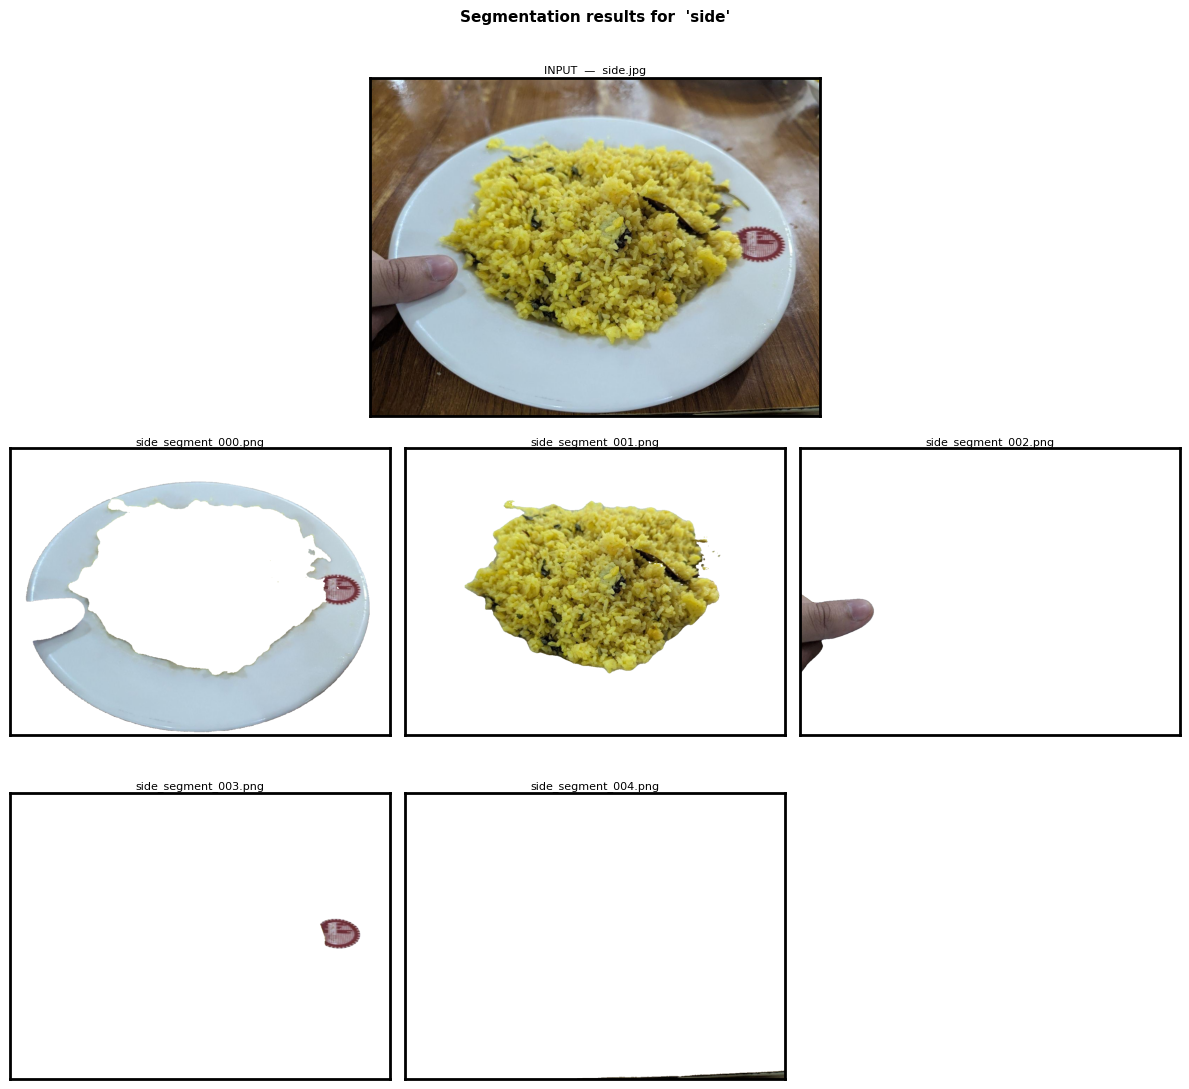

✔ 'side' — 5 segments shown



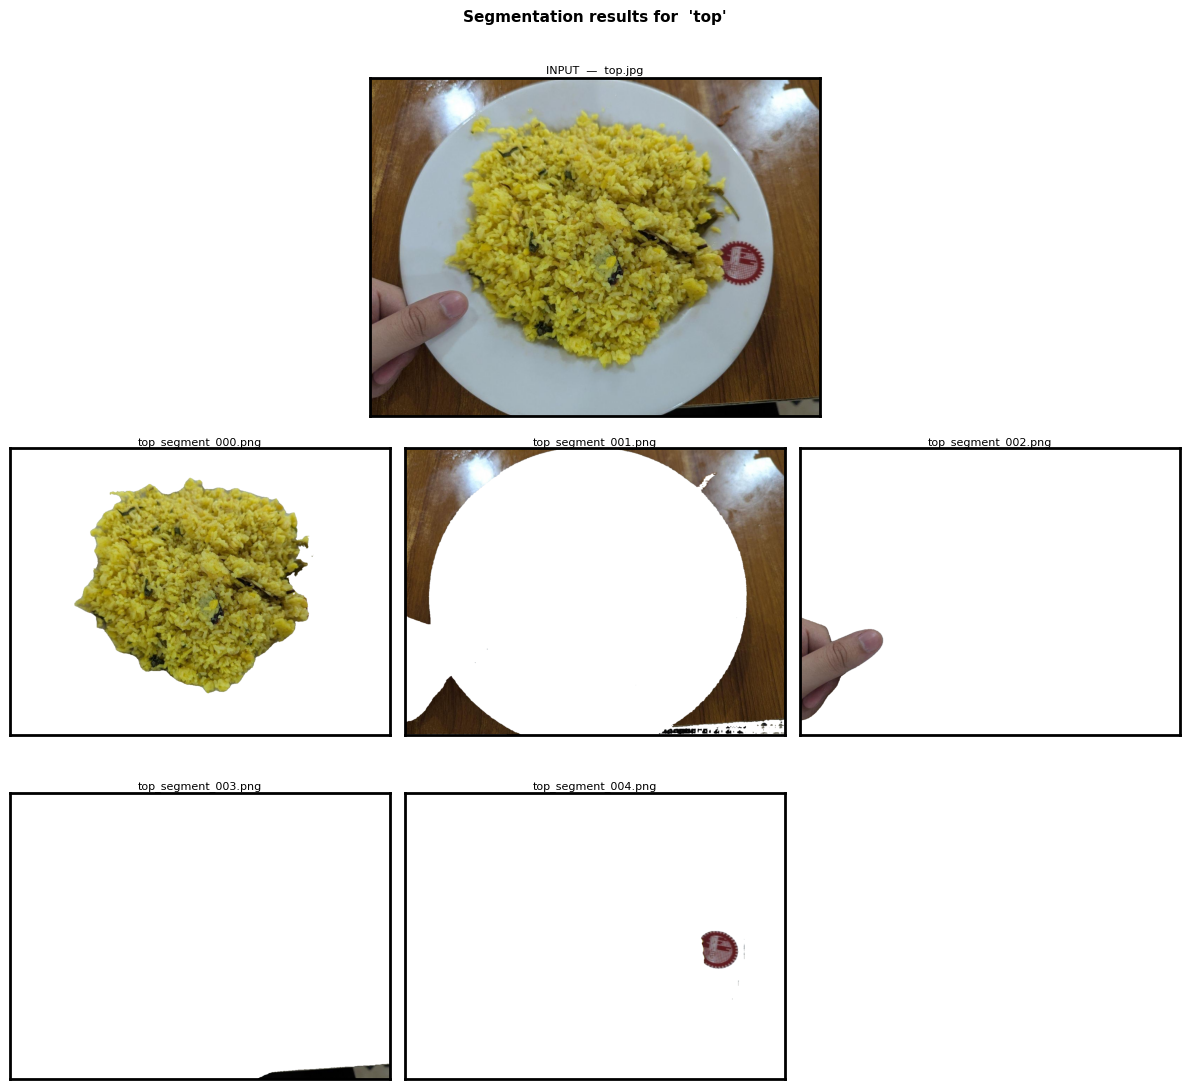

✔ 'top' — 5 segments shown



In [14]:
def seg_main():
    """
    Main function to run batch segmentation on all images in INPUT_DIR
    and display the results.
    """
    # =============================
    # CONFIGURATION
    # =============================
    INPUT_DIR  = "/kaggle/working/input_images"
    OUTPUT_DIR = "/kaggle/working/segmentation-outputs"

    CHECKPOINT   = "/kaggle/input/datasets/ifty3110/segmentation-module-checkpoints-config/checkpoints/sam2_hiera_large.pt"
    MODEL_CONFIG = "sam2_hiera_l.yaml"
    DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

    SUPPORTED_EXTENSIONS = (".jpg", ".jpeg", ".png")

    coords_dir   = os.path.join(OUTPUT_DIR, "coordinates")
    masks_dir    = os.path.join(OUTPUT_DIR, "masks")
    segments_dir = os.path.join(OUTPUT_DIR, "segments")

    for d in [coords_dir, masks_dir, segments_dir]:
        os.makedirs(d, exist_ok=True)

    print(f"Input      : {INPUT_DIR}")
    print(f"Output     : {OUTPUT_DIR}")
    print(f"Device     : {DEVICE}")
    print(f"Checkpoint : {CHECKPOINT}")
    print(f"Exists     : {os.path.exists(CHECKPOINT)}")

    # =============================
    # INSTANTIATE
    # =============================
    print("\nInitializing SegmentationModule...")
    seg = SegmentationModule(
        checkpoint   = CHECKPOINT,
        model_config = MODEL_CONFIG,
        device       = DEVICE,
    )
    seg.min_area_ratio       = 0.02
    seg.min_mask_region_area = 100
    seg.dedup_iou_threshold  = 0.5
    print("✓ Model loaded and ready.")

    # =============================
    # BATCH PROCESSING LOOP
    # =============================
    image_files = [
        f for f in os.listdir(INPUT_DIR)
        if f.lower().endswith(SUPPORTED_EXTENSIONS)
    ]
    print(f"\nFound {len(image_files)} images in {INPUT_DIR}\n")

    total_start = time.time()

    for filename in image_files:
        image_path = os.path.join(INPUT_DIR, filename)
        base_name  = os.path.splitext(filename)[0]

        print(f"Processing: {filename}")
        t0 = time.time()

        img_coords_dir   = os.path.join(coords_dir,   base_name)
        img_masks_dir    = os.path.join(masks_dir,    base_name)
        img_segments_dir = os.path.join(segments_dir, base_name)
        for d in [img_coords_dir, img_masks_dir, img_segments_dir]:
            os.makedirs(d, exist_ok=True)

        seg.set_image_from_path(image_path)

        # 1. COORDINATES → JSON
        coordinates = seg.get_coordinates()
        for coord in coordinates:
            sid      = coord["segment_id"]
            out_path = os.path.join(img_coords_dir, f"{base_name}_coord_{sid:03d}.json")
            with open(out_path, "w") as f:
                json.dump(coord, f, indent=4)
        print(f"  ✔ Coordinates saved  ({len(coordinates)} segments)")

        # 2. MASKS → NPY
        masks = seg.get_masks()
        for mask_data in masks:
            sid      = mask_data["segment_id"]
            out_path = os.path.join(img_masks_dir, f"{base_name}_mask_{sid:03d}.npy")
            np.save(out_path, mask_data["mask"])
        print(f"  ✔ Masks saved        ({len(masks)} segments)")

        # 3. SEGMENTS → PNG
        segments = seg.get_segments()
        for segment in segments:
            sid      = segment["segment_id"]
            out_path = os.path.join(img_segments_dir, f"{base_name}_segment_{sid:03d}.png")
            segment["image"].save(out_path)
        print(f"  ✔ Segments saved     ({len(segments)} segments)")

        elapsed = time.time() - t0
        print(f"  ⏱  {elapsed:.2f}s\n")

        seg.clear_cache()

    total_elapsed = time.time() - total_start
    print(f"All done! Total time: {total_elapsed:.2f}s")
    print(f"Output written to: {OUTPUT_DIR}")

    # =============================
    # DISPLAY RESULTS
    # =============================
    seg.display_all_segments(INPUT_DIR, segments_dir)


if __name__ == "__main__":
    seg_main()

In [15]:
################################
################################
################################
# thumb detection and calibration
################################
################################
################################

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s] 


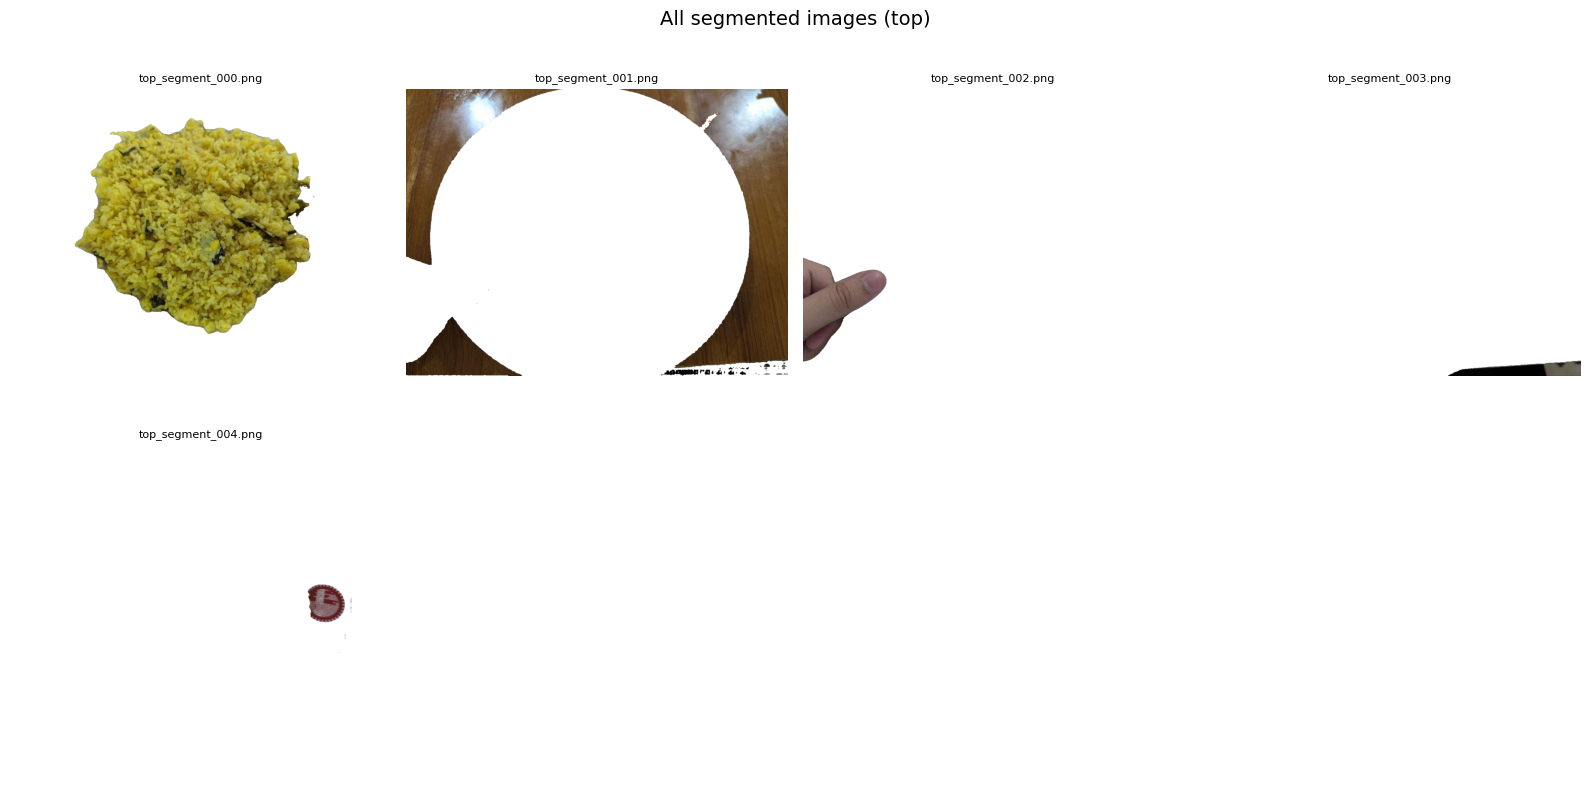

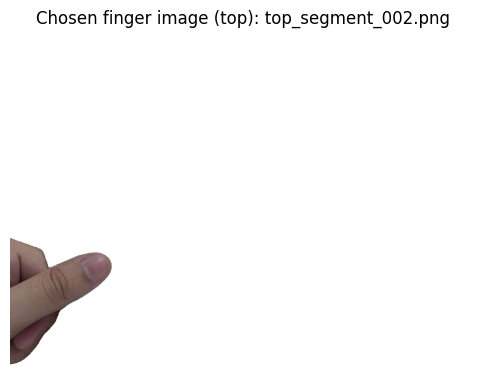

Saved JSON: /kaggle/working/top_view_finger_image_result.json
Saved TXT: /kaggle/working/top_view_finger_image_cm_per_pixel.txt
Copied 4 images (excluding finger image) to /kaggle/working/top_segments


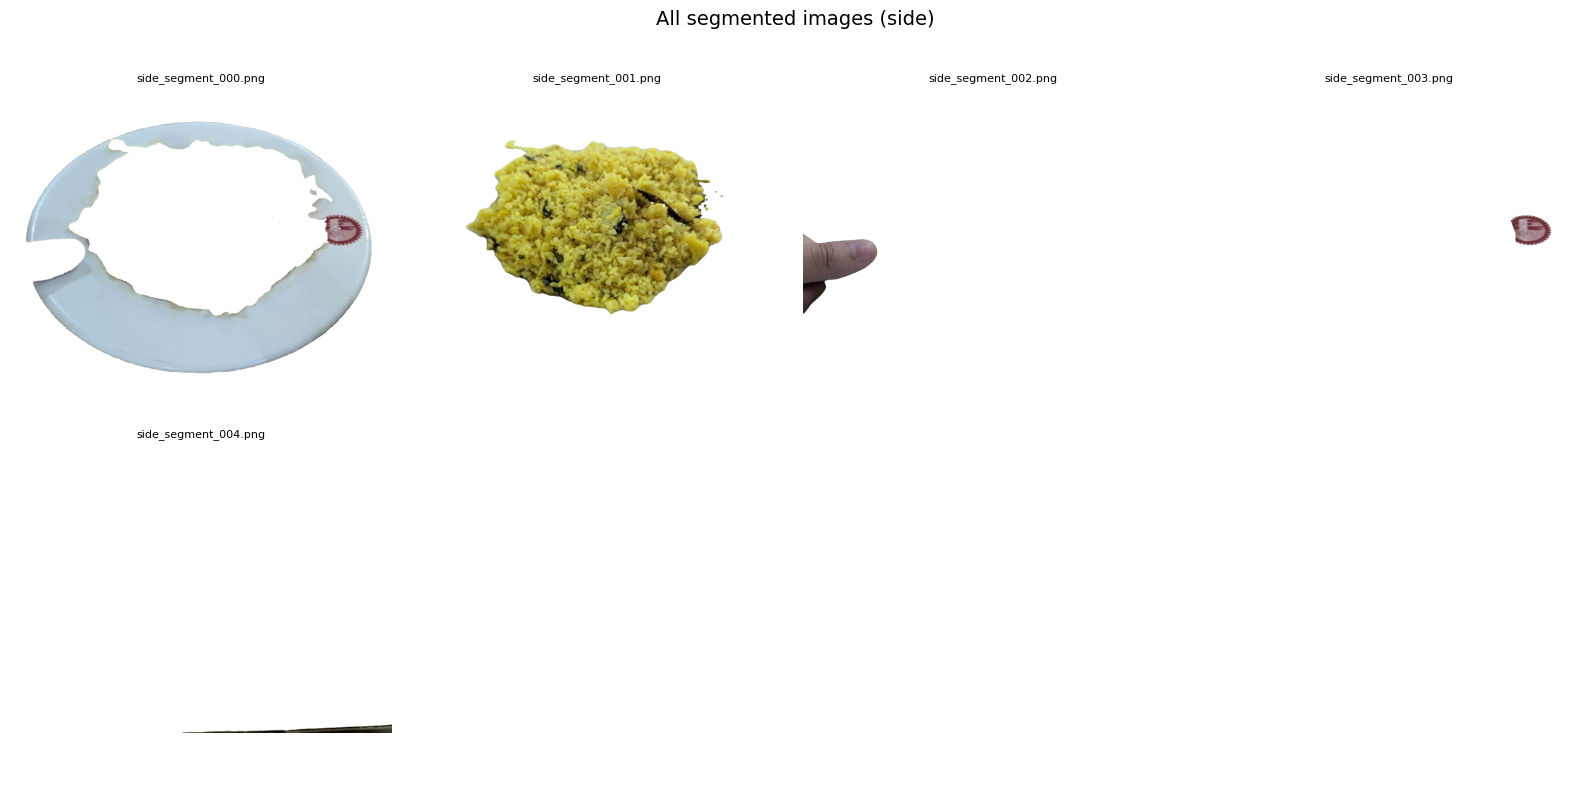

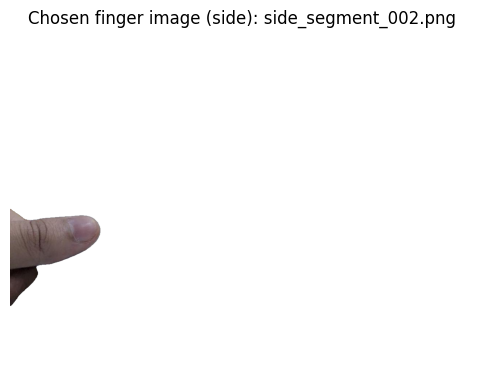

Saved JSON: /kaggle/working/side_view_finger_image_result.json
Saved TXT: /kaggle/working/side_view_finger_image_cm_per_pixel.txt
Copied 4 images (excluding finger image) to /kaggle/working/side_segments
Top cm_per_pixel: 0.011383824216923796
Side cm_per_pixel: 0.014344948265368227


In [16]:
# Cell 2: Usage
from __future__ import annotations
from pathlib import Path


# Set segmented images for top and side views 
SEGMENTED_TOP_DIR = Path('/kaggle/working/segmentation-outputs/segments/top')
SEGMENTED_SIDE_DIR = Path('/kaggle/working/segmentation-outputs/segments/side')
MODEL_PATH = CALIBRATION_PKG_DIR / 'finger_detector.joblib'
ALLOW_LOW_CONFIDENCE = True

# !rm -rf /kaggle/working/*

# Create and load the module once
module = FingerDetectorAndCalibrator()
module.load_model(MODEL_PATH)

# Process both views using the method defined in Cell 1
result_top = module.process_view(
    'top',
    SEGMENTED_TOP_DIR,
    allow_low_confidence=ALLOW_LOW_CONFIDENCE,
    work_dir=WORK_DIR,
)
result_side = module.process_view(
    'side',
    SEGMENTED_SIDE_DIR,
    allow_low_confidence=ALLOW_LOW_CONFIDENCE,
    work_dir=WORK_DIR,
)

print('Top cm_per_pixel:', result_top['calibration']['cm_per_pixel'])
print('Side cm_per_pixel:', result_side['calibration']['cm_per_pixel'])

In [17]:
################################
################################
################################
# classfication 
################################
################################
################################

Initializing Food Classifier...
✓ Classifier initialized successfully

--- Processing folder: /kaggle/working/top_segments/ ---


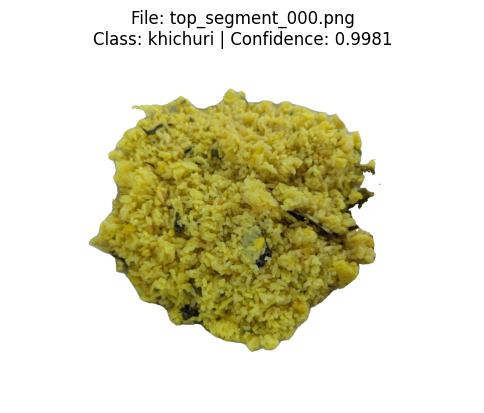

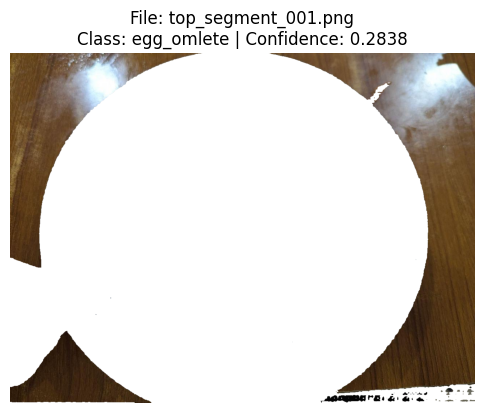

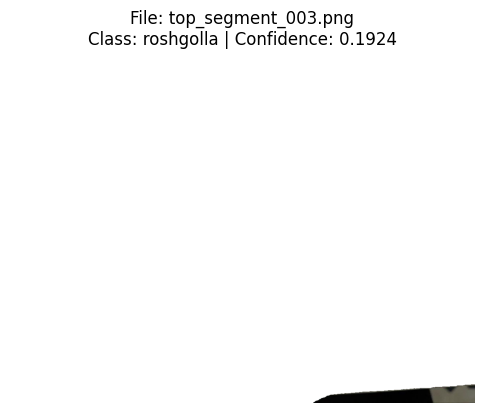

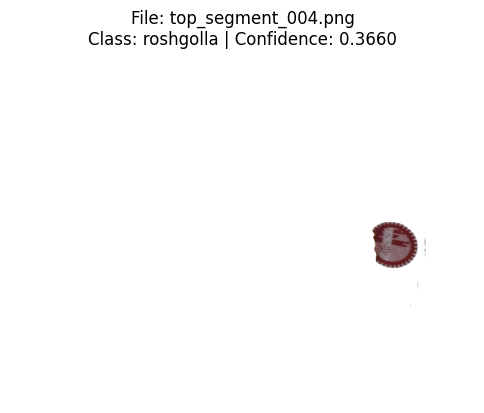


--- Processing folder: /kaggle/working/side_segments/ ---


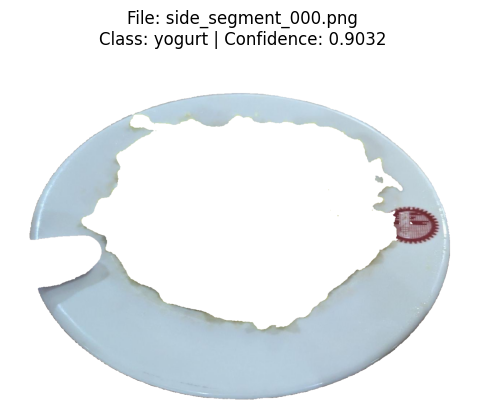

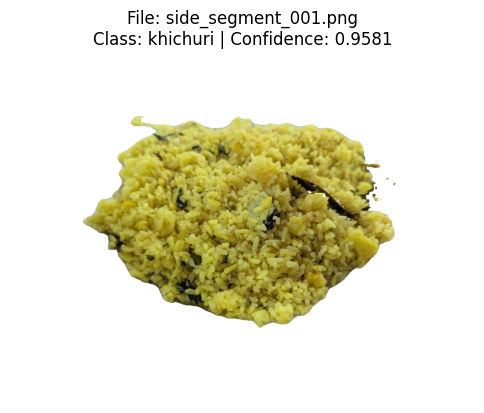

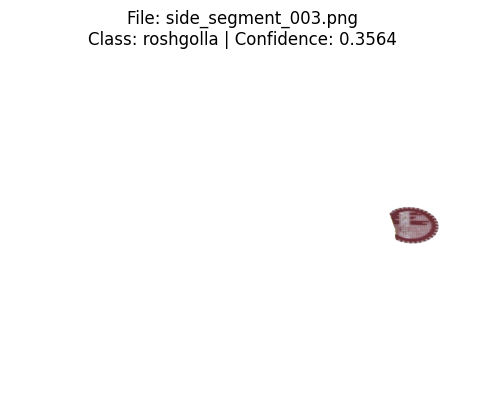

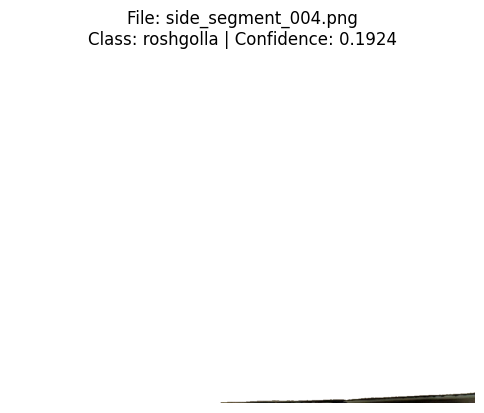

In [18]:
def class_main():
    print("Initializing Food Classifier...")
    classifier = FoodClassifier()
    print("✓ Classifier initialized successfully")

    DIRECTORY_PATH = "/kaggle/working/"

    classifier.classify_and_display_folder(DIRECTORY_PATH + "top_segments/")
    classifier.classify_and_display_folder(DIRECTORY_PATH + "side_segments/")

    valid_labels = classifier.classify_and_copy_folder(DIRECTORY_PATH + "top_segments/","categorized_top", 0.8)
    classifier.classify_and_copy_folder_with_label_filter(DIRECTORY_PATH + "side_segments/","categorized_side", valid_labels, 0.8)

if __name__ == "__main__":
    class_main()

In [19]:
################################
################################
################################
# volume estimation 
################################
################################
################################

In [20]:
import sys
sys.path.insert(0, '/kaggle/working')
if 'module' in sys.modules:
    del sys.modules['module']  # force re-import of the freshly written module.py
import module
import json

"""
usage.py
========
Drives `module.py` against the NEW folder layout:

    capstone-demonstration/
        coordinates/
        masks/
            input_4_side/      <-- flat .npy masks (side view)
            input_4_top/       <-- flat .npy masks (top view)
        segments/
        filtered_side/
            porota/             <-- classified .png/.jpg files (side view)
            roshgolla/
        filtered_top/
            porota/             <-- classified .png/.jpg files (top view)
            roshgolla/

The classification step (a separate module) only produced
filtered_side/<class>/*.png and filtered_top/<class>/*.png — i.e. it
re-sorted the *images*, not the masks. Before running the volume
algorithm we must reorganize the matching .npy masks into the same
class structure:

    masks/input_4_side/*.npy  +  filtered_side/<class>/*.png
        -->  filtered_side_npy/<class>/*.npy

    masks/input_4_top/*.npy   +  filtered_top/<class>/*.png
        -->  filtered_top_npy/<class>/*.npy

After that, the ORIGINAL, UNCHANGED volume-estimation algorithm in
module.py is run exactly as before — only the input plumbing changed.
"""

import os
from pathlib import Path



# ============================================================================
# CONFIGURATION — Kaggle paths
# ============================================================================

# Kaggle input datasets (read-only)
INPUT_FOOD_DIR = Path("/kaggle/working")
INPUT_IMAGE_DIR = Path("/kaggle/working/input_images")

# Kaggle output directory (writable) — reorganized .npy masks go here
OUTPUT_ROOT = Path("/kaggle/working")

# Subfolder containing raw mask inputs (inside the input-food dataset)
MASKS_ROOT = INPUT_FOOD_DIR / "segmentation-outputs"

# Two main view images — UNCHANGED, as before

def find_image_with_keyword(folder, keyword):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp', '.gif')
    candidates = [f for f in os.listdir(folder)
                  if keyword.lower() in f.lower() and f.lower().endswith(exts)]
    if not candidates:
        raise FileNotFoundError(f"No image containing '{keyword}' found in {folder}")
    return candidates[0]

IMAGES_DIR = INPUT_IMAGE_DIR
IMAGE_SIDE_FILENAME = find_image_with_keyword(IMAGES_DIR, "side")
IMAGE_TOP_FILENAME  = find_image_with_keyword(IMAGES_DIR, "top")

# Flat folders of raw .npy masks (one per view), produced by Module 1 (SAM)
MASKS_SIDE_DIR = MASKS_ROOT / "masks" / "side"
MASKS_TOP_DIR = MASKS_ROOT / "masks" / "top"

# Classified image folders, produced by the classification module
FILTERED_SIDE_DIR = INPUT_FOOD_DIR / "categorized_side"
FILTERED_TOP_DIR = INPUT_FOOD_DIR / "categorized_top"

# Where the reorganized .npy masks will be written (MUST be writable,
# so this lives under /kaggle/working — /kaggle/input is read-only)
FILTERED_SIDE_NPY_DIR = OUTPUT_ROOT / "categorized_side_npy"
FILTERED_TOP_NPY_DIR = OUTPUT_ROOT / "categorized_top_npy"

# Calibration (from Module 3)
CM_PER_PIXEL_PATH = "/kaggle/working/side_view_finger_image_cm_per_pixel.txt"

with open(CM_PER_PIXEL_PATH, "r") as f:
    cm_per_pixel = float(f.read().strip())

PIXEL_LENGTH_MM = cm_per_pixel * 10
VOXEL_SIZE_MM = 20


# ============================================================================
# STEP 0: Reorganize flat .npy masks into the classified folder structure
# ============================================================================

def preview_inputs():
    """Quick sanity check: list what's actually on disk before reorganizing."""
    print("\n" + "=" * 60)
    print("PRE-FLIGHT CHECK: input folders")
    print("=" * 60)

    for label, folder in [
        ("MASKS_SIDE_DIR", MASKS_SIDE_DIR),
        ("MASKS_TOP_DIR", MASKS_TOP_DIR),
        ("FILTERED_SIDE_DIR", FILTERED_SIDE_DIR),
        ("FILTERED_TOP_DIR", FILTERED_TOP_DIR),
    ]:
        if not Path(folder).exists():
            print(f"❌ {label}: {folder}  <-- DOES NOT EXIST")
            continue
        if "MASKS" in label:
            files = sorted(Path(folder).glob("*.npy"))
        else:
            files = sorted(f for f in Path(folder).rglob("*") if f.is_file())
        print(f"✅ {label}: {folder}  ({len(files)} files)")
        for f in files[:5]:
            print(f"      - {f.name}")
        if len(files) > 5:
            print(f"      ... and {len(files) - 5} more")


def reorganize_masks():
    print("\n" + "=" * 60)
    print("STEP 0: Reorganizing .npy masks into classified folders")
    print("=" * 60)

    print("\n-- Side view --")
    module.organize_npy_files(
        source_folder=MASKS_SIDE_DIR,
        configuration_folder=FILTERED_SIDE_DIR,
        output_folder=FILTERED_SIDE_NPY_DIR,
    )

    print("\n-- Top view --")
    module.organize_npy_files(
        source_folder=MASKS_TOP_DIR,
        configuration_folder=FILTERED_TOP_DIR,
        output_folder=FILTERED_TOP_NPY_DIR,
    )


# ============================================================================
# STEP 1: Collect, per class, the list of .npy mask paths for each view
# ============================================================================

def collect_class_npy_paths(npy_root: Path):
    """
    npy_root/
        porota/
            one.npy
        roshgolla/
            two.npy
            three.npy

    Returns: { "porota": [".../one.npy"], "roshgolla": [".../two.npy", ".../three.npy"] }
    """
    classes = {}
    if not npy_root.exists():
        print(f"⚠️  {npy_root} does not exist")
        return classes

    for class_dir in sorted(p for p in npy_root.iterdir() if p.is_dir()):
        npy_files = sorted(class_dir.glob("*.npy"))
        if npy_files:
            classes[class_dir.name] = [str(p) for p in npy_files]
    return classes


# ============================================================================
# STEP 2: Build flattened (npy_paths, class_ids) lists for parse_npy_segments
# ============================================================================

def build_paths_and_labels(class_to_paths: dict):
    """
    Flatten { class_name: [path, ...] } into
        npy_paths = [path1, path2, ...]
        class_ids = [class_name1, class_name1, class_name2, ...]
    (one class label per path, matching module.parse_npy_segments expectations)
    """
    npy_paths = []
    class_ids = []
    for class_name, paths in class_to_paths.items():
        for p in paths:
            npy_paths.append(p)
            class_ids.append(class_name)
    return npy_paths, class_ids


# ============================================================================
# MAIN WORKFLOW
# ============================================================================

def main():
    # ---- Step -1: show what's actually on disk ----------------------------
    preview_inputs()

    # ---- Step 0: reorganize raw .npy masks to match classified images ----
    reorganize_masks()

    # ---- Step 1: gather classified npy paths per view --------------------
    side_classes = collect_class_npy_paths(FILTERED_SIDE_NPY_DIR)
    top_classes = collect_class_npy_paths(FILTERED_TOP_NPY_DIR)

    print("\nClasses found (side):", list(side_classes.keys()))
    print("Classes found (top) :", list(top_classes.keys()))

    side_npy_paths, side_class_ids = build_paths_and_labels(side_classes)
    top_npy_paths, top_class_ids = build_paths_and_labels(top_classes)

    # ---- Step 2: load the two main images (unchanged) --------------------
    print("\nLoading images...")
    image_side = module.load_image_file(os.path.join(IMAGES_DIR, IMAGE_SIDE_FILENAME))
    image_top = module.load_image_file(os.path.join(IMAGES_DIR, IMAGE_TOP_FILENAME))

    # ---- Step 3: parse npy masks -> segment dicts (unchanged algorithm) --
    print("\nParsing masks for SIDE view...")
    segments_side = module.parse_npy_segments(
        image=image_side,
        npy_paths=side_npy_paths,
        class_ids=side_class_ids,
    )

    print("\nParsing masks for TOP view...")
    segments_top = module.parse_npy_segments(
        image=image_top,
        npy_paths=top_npy_paths,
        class_ids=top_class_ids,
    )

    print(f"\nSide view: {len(segments_side)} segment(s) ready")
    print(f"Top view : {len(segments_top)} segment(s) ready")

    # ---- Step 4: run the UNCHANGED multi-item volume algorithm -----------
    all_results = module.calculate_volume_all_items(
        img1=image_top,
        img2=image_side,
        segments1=segments_top,
        segments2=segments_side,
        pixel_length_mm=PIXEL_LENGTH_MM,
        voxel_size_mm=VOXEL_SIZE_MM,
    )

    # ---- Step 5: print final results --------------------------------------
    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)
    for food_label, result in all_results.items():
        if not result:
            continue
        print(f"food name: {food_label}")
        print(f"volume: {result['volume_cm3']:.4f} cm cube")
        print(f"  voxels             : {result['num_voxels']}")
        print(f"  points             : {result['num_points']}")
        print(f"  pixel count        : {result['pixel_count']}")
        print(f"  shape correction   : {result['shape_correction']}")
        print()

    # ---- Step 6: merge per-item volumes into ONE total volume per class --
    merged_volumes = module.aggregate_volumes_by_class(all_results)

    # ---- Step 7: save classification name -> total volume as JSON -------
    # (written to /kaggle/working since /kaggle/input is read-only)
    output_json_path = OUTPUT_ROOT / "food_volumes_summary.json"
    with open(output_json_path, "w") as f:
        json.dump(merged_volumes, f, indent=2)

    print(f"\n✅ Saved merged classification volumes to: {output_json_path}")
    print(json.dumps(merged_volumes, indent=2))

    return all_results, merged_volumes


if __name__ == "__main__":
    main()


PRE-FLIGHT CHECK: input folders
✅ MASKS_SIDE_DIR: /kaggle/working/segmentation-outputs/masks/side  (5 files)
      - side_mask_000.npy
      - side_mask_001.npy
      - side_mask_002.npy
      - side_mask_003.npy
      - side_mask_004.npy
✅ MASKS_TOP_DIR: /kaggle/working/segmentation-outputs/masks/top  (5 files)
      - top_mask_000.npy
      - top_mask_001.npy
      - top_mask_002.npy
      - top_mask_003.npy
      - top_mask_004.npy
✅ FILTERED_SIDE_DIR: /kaggle/working/categorized_side  (1 files)
      - side_segment_001.png
✅ FILTERED_TOP_DIR: /kaggle/working/categorized_top  (1 files)
      - top_segment_000.png

STEP 0: Reorganizing .npy masks into classified folders

-- Side view --
   source_folder        : /kaggle/working/segmentation-outputs/masks/side  (5 .npy files)
   configuration_folder : /kaggle/working/categorized_side  (1 files)
   ℹ️  Number-matched 'side_segment_001.png' -> 'side_mask_001.npy' (index 1)

   Matched & copied : 1/1 file(s)
Finished organizing files.



In [21]:
################################
################################
################################
# Processing Final output 
################################
################################
################################

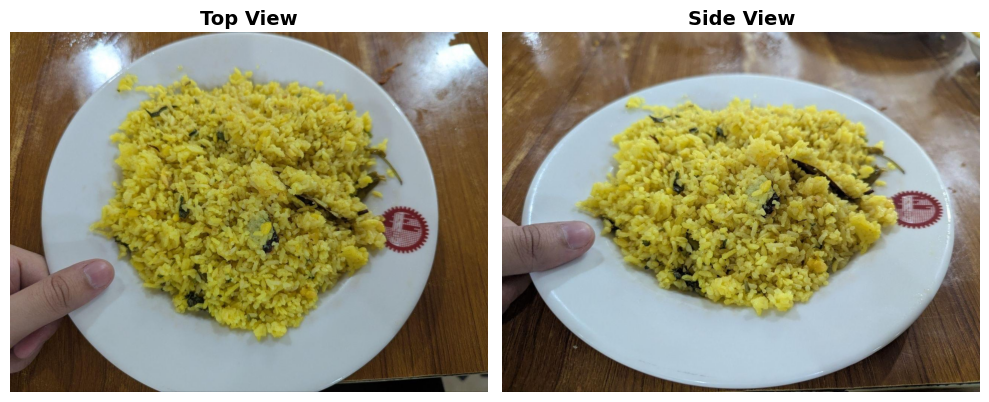


══════════════════════════════════════════════════════════
                 🍽  DIET NUTRITION REPORT                 
══════════════════════════════════════════════════════════

┌─ KHICHURI (96 cm³)
│  🔥 Calories   : 143.0 kcal
│
│  MACROS
│  🌾 Carbs      : 21.12g 
│  🥩 Protein    : 4.8g 
│  🫙 Fat        : 3.84g 
│  🌿 Fiber      : 2.4g 
│
│  MINERALS & VITAMINS
│  🧂 Sodium     : 28.8mg   💪 Calcium: 2.9mg   🩸 Iron: 0.96mg
│  🥕 Vit A      : 28.8µg    🍋 Vit C : 9.6mg    ☀  Vit D: 0.0µg
└───────────────────────────────────────────────────────

══════════════════════════════════════════════════════════
                  📋  TOTAL MEAL SUMMARY                   
══════════════════════════════════════════════════════════
  🔥 Total Calories  : 143.0 kcal
  🌾 Total Carbs     : 21.12g
  🥩 Total Protein   : 4.8g
  🫙 Total Fat       : 3.84g
  🌿 Total Fiber     : 2.4g
  🧂 Total Sodium    : 28.8mg
  💪 Total Calcium   : 2.9mg
  🩸 Total Iron      : 0.96mg
  🥕 Total Vit A     : 28.8µg
  🍋 Total Vit C  

In [22]:
import os
import json

def analyze_food_volume(input_json_path, output_json_path="food_nutrition_report.json"):

    KCAL_PER_G = {"carbohydrates": 4, "protein": 4, "fat": 9, "fiber": 2}

    nutrition_kb = {
        "hilsha_fish":   {"carbohydrates":0.00,"fiber":0.00,"protein":0.22,"fat":0.19,"sodium_mg":0.55,"calcium_mg":0.18,"iron_mg":0.014,"vit_a_ug":0.6,"vit_c_mg":0.0,"vit_d_ug":0.8},
        "biriyani":      {"carbohydrates":0.32,"fiber":0.015,"protein":0.09,"fat":0.14,"sodium_mg":0.50,"calcium_mg":0.04,"iron_mg":0.008,"vit_a_ug":0.5,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "khichuri":      {"carbohydrates":0.22,"fiber":0.025,"protein":0.05,"fat":0.04,"sodium_mg":0.30,"calcium_mg":0.03,"iron_mg":0.010,"vit_a_ug":0.3,"vit_c_mg":0.1,"vit_d_ug":0.0},
        "morog_polao":   {"carbohydrates":0.28,"fiber":0.012,"protein":0.11,"fat":0.13,"sodium_mg":0.45,"calcium_mg":0.03,"iron_mg":0.007,"vit_a_ug":0.4,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "yogurt":        {"carbohydrates":0.05,"fiber":0.00,"protein":0.04,"fat":0.04,"sodium_mg":0.17,"calcium_mg":0.12,"iron_mg":0.001,"vit_a_ug":0.5,"vit_c_mg":0.5,"vit_d_ug":0.1},
        "roshgolla":     {"carbohydrates":0.38,"fiber":0.00,"protein":0.04,"fat":0.02,"sodium_mg":0.10,"calcium_mg":0.07,"iron_mg":0.002,"vit_a_ug":0.1,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "porota":        {"carbohydrates":0.35,"fiber":0.02,"protein":0.06,"fat":0.12,"sodium_mg":0.40,"calcium_mg":0.02,"iron_mg":0.006,"vit_a_ug":0.0,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "bakorkhani":    {"carbohydrates":0.45,"fiber":0.025,"protein":0.08,"fat":0.18,"sodium_mg":0.55,"calcium_mg":0.03,"iron_mg":0.007,"vit_a_ug":0.0,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "fuchka":        {"carbohydrates":0.20,"fiber":0.03,"protein":0.04,"fat":0.06,"sodium_mg":0.60,"calcium_mg":0.02,"iron_mg":0.012,"vit_a_ug":0.1,"vit_c_mg":1.5,"vit_d_ug":0.0},
        "roshmalai":     {"carbohydrates":0.42,"fiber":0.00,"protein":0.06,"fat":0.08,"sodium_mg":0.12,"calcium_mg":0.10,"iron_mg":0.002,"vit_a_ug":0.3,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "kacha_golla":   {"carbohydrates":0.40,"fiber":0.00,"protein":0.08,"fat":0.07,"sodium_mg":0.08,"calcium_mg":0.09,"iron_mg":0.002,"vit_a_ug":0.2,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "kala_bhuna":    {"carbohydrates":0.04,"fiber":0.005,"protein":0.24,"fat":0.22,"sodium_mg":0.80,"calcium_mg":0.02,"iron_mg":0.025,"vit_a_ug":0.2,"vit_c_mg":0.5,"vit_d_ug":0.0},
        "haleem":        {"carbohydrates":0.16,"fiber":0.035,"protein":0.09,"fat":0.07,"sodium_mg":0.55,"calcium_mg":0.04,"iron_mg":0.018,"vit_a_ug":0.1,"vit_c_mg":0.3,"vit_d_ug":0.0},
        "mashed_potato": {"carbohydrates":0.15,"fiber":0.02,"protein":0.02,"fat":0.03,"sodium_mg":0.25,"calcium_mg":0.01,"iron_mg":0.004,"vit_a_ug":0.0,"vit_c_mg":3.0,"vit_d_ug":0.0},
        "nehari":        {"carbohydrates":0.02,"fiber":0.00,"protein":0.12,"fat":0.15,"sodium_mg":0.70,"calcium_mg":0.04,"iron_mg":0.020,"vit_a_ug":0.1,"vit_c_mg":0.0,"vit_d_ug":0.0},
        "kabab":         {"carbohydrates":0.05,"fiber":0.01,"protein":0.20,"fat":0.14,"sodium_mg":0.60,"calcium_mg":0.02,"iron_mg":0.022,"vit_a_ug":0.1,"vit_c_mg":0.2,"vit_d_ug":0.0},
        "egg_omlete":    {"carbohydrates":0.01,"fiber":0.00,"protein":0.11,"fat":0.12,"sodium_mg":0.55,"calcium_mg":0.05,"iron_mg":0.015,"vit_a_ug":1.5,"vit_c_mg":0.0,"vit_d_ug":0.9},
        "beguni":        {"carbohydrates":0.18,"fiber":0.02,"protein":0.03,"fat":0.16,"sodium_mg":0.30,"calcium_mg":0.01,"iron_mg":0.005,"vit_a_ug":0.0,"vit_c_mg":0.8,"vit_d_ug":0.0},
        "chickpeas":     {"carbohydrates":0.24,"fiber":0.07,"protein":0.08,"fat":0.05,"sodium_mg":0.15,"calcium_mg":0.05,"iron_mg":0.025,"vit_a_ug":0.1,"vit_c_mg":0.5,"vit_d_ug":0.0},
    }

    def bar(val, total, width=20):
        filled = int((val / total) * width) if total else 0
        return "█" * filled + "░" * (width - filled)

    MACRO_MAX = {"carbs": 275, "protein": 50, "fat": 78, "fiber": 28}

    if not os.path.exists(input_json_path):
        print(f"Error: '{input_json_path}' does not exist.")
        return

    with open(input_json_path, 'r') as f:
        try:
            input_data = json.load(f)
        except json.JSONDecodeError:
            print("Error: Invalid JSON format.")
            return

    report = {}
    meal_totals = {k: 0.0 for k in ["calories_kcal","carbohydrates_g","fiber_g","protein_g","fat_g","sodium_mg","calcium_mg","iron_mg","vit_a_ug","vit_c_mg","vit_d_ug"]}

    print("\n" + "═" * 58)
    print(f"{'🍽  DIET NUTRITION REPORT':^58}")
    print("═" * 58)

    for food_name, volume in input_data.items():
        key = food_name.strip().lower()
        if key not in nutrition_kb:
            print(f"\n⚠  '{food_name}' not recognized — skipping.")
            continue

        d = nutrition_kb[key]
        carbs   = round(d["carbohydrates"] * volume, 2)
        fiber   = round(d["fiber"] * volume, 2)
        protein = round(d["protein"] * volume, 2)
        fat     = round(d["fat"] * volume, 2)
        sodium  = round(d["sodium_mg"] * volume, 1)
        calcium = round(d["calcium_mg"] * volume, 1)
        iron    = round(d["iron_mg"] * volume, 2)
        vit_a   = round(d["vit_a_ug"] * volume, 1)
        vit_c   = round(d["vit_c_mg"] * volume, 1)
        vit_d   = round(d["vit_d_ug"] * volume, 2)

        calories = round(
            carbs * KCAL_PER_G["carbohydrates"] +
            protein * KCAL_PER_G["protein"] +
            fat * KCAL_PER_G["fat"] +
            fiber * KCAL_PER_G["fiber"], 1
        )

        total_macro_g = carbs + protein + fat + fiber
        c_pct = round(carbs / total_macro_g * 100) if total_macro_g else 0
        p_pct = round(protein / total_macro_g * 100) if total_macro_g else 0
        f_pct = round(fat / total_macro_g * 100) if total_macro_g else 0

        for k, v in [("calories_kcal",calories),("carbohydrates_g",carbs),("fiber_g",fiber),
                     ("protein_g",protein),("fat_g",fat),("sodium_mg",sodium),
                     ("calcium_mg",calcium),("iron_mg",iron),("vit_a_ug",vit_a),
                     ("vit_c_mg",vit_c),("vit_d_ug",vit_d)]:
            meal_totals[k] = round(meal_totals[k] + v, 2)

        report[food_name] = {
            "volume_cm3": volume,
            "calories_kcal": calories,
            "macros": {"carbohydrates_g":carbs,"fiber_g":fiber,"protein_g":protein,"fat_g":fat},
            "macro_split_%": {"carbs":c_pct,"protein":p_pct,"fat":f_pct},
            "minerals": {"sodium_mg":sodium,"calcium_mg":calcium,"iron_mg":iron},
            "vitamins": {"vit_a_ug":vit_a,"vit_c_mg":vit_c,"vit_d_ug":vit_d},
        }

        print(f"\n┌─ {food_name.upper().replace('_',' ')} ({'%.0f' % volume} cm³)")
        print(f"│  🔥 Calories   : {calories} kcal")
        print(f"│")
        print(f"│  MACROS")
        print(f"│  🌾 Carbs      : {carbs}g ")
        print(f"│  🥩 Protein    : {protein}g ")
        print(f"│  🫙 Fat        : {fat}g ")
        print(f"│  🌿 Fiber      : {fiber}g ")
        print(f"│")
        print(f"│  MINERALS & VITAMINS")
        print(f"│  🧂 Sodium     : {sodium}mg   💪 Calcium: {calcium}mg   🩸 Iron: {iron}mg")
        print(f"│  🥕 Vit A      : {vit_a}µg    🍋 Vit C : {vit_c}mg    ☀  Vit D: {vit_d}µg")
        print(f"└{'─'*55}")

    # ── MEAL SUMMARY ───────────────────────────────────────────────────────────
    print(f"\n{'═'*58}")
    print(f"{'📋  TOTAL MEAL SUMMARY':^58}")
    print(f"{'═'*58}")
    print(f"  🔥 Total Calories  : {meal_totals['calories_kcal']} kcal")
    print(f"  🌾 Total Carbs     : {meal_totals['carbohydrates_g']}g")
    print(f"  🥩 Total Protein   : {meal_totals['protein_g']}g")
    print(f"  🫙 Total Fat       : {meal_totals['fat_g']}g")
    print(f"  🌿 Total Fiber     : {meal_totals['fiber_g']}g")
    print(f"  🧂 Total Sodium    : {meal_totals['sodium_mg']}mg")
    print(f"  💪 Total Calcium   : {meal_totals['calcium_mg']}mg")
    print(f"  🩸 Total Iron      : {meal_totals['iron_mg']}mg")
    print(f"  🥕 Total Vit A     : {meal_totals['vit_a_ug']}µg")
    print(f"  🍋 Total Vit C     : {meal_totals['vit_c_mg']}mg")
    print(f"  ☀  Total Vit D     : {meal_totals['vit_d_ug']}µg")
    print(f"{'═'*58}\n")

    final_output = {
        "per_food_breakdown": report,
        "meal_totals": meal_totals,
    }

    with open(output_json_path, 'w') as out:
        json.dump(final_output, out, indent=2)

    print(f"[✓] Report saved → {output_json_path}\n")


def display_food_views(folder_path):
    valid_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    top_image_path = None
    side_image_path = None

    for file in os.listdir(folder_path):
        name, ext = os.path.splitext(file)
        if ext in valid_extensions:
            if name.lower() == 'top':
                top_image_path = os.path.join(folder_path, file)
            elif name.lower() == 'side':
                side_image_path = os.path.join(folder_path, file)

    if not top_image_path or not side_image_path:
        print("Error: Could not find both 'top' and 'side' images in the folder.")
        if top_image_path: print(f"Found top view: {top_image_path}")
        if side_image_path: print(f"Found side view: {side_image_path}")
        return

    try:
        top_img = Image.open(top_image_path)
        side_img = Image.open(side_image_path)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(top_img)
        axes[0].set_title("Top View", fontsize=14, fontweight='bold')
        axes[0].axis('off')
        axes[1].imshow(side_img)
        axes[1].set_title("Side View", fontsize=14, fontweight='bold')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"An error occurred while loading or displaying the images: {e}")


display_food_views("/kaggle/working/input_images")
analyze_food_volume("food_volumes_summary.json", "final_nutrition_output.json")